# Ryazanov Dmitriy 
# DS-02 
# d.ryazanov@innopolis.university
#
# Case Study: Relation Extraction for KG Construction

In [1]:
import gc
import os
import random
import re
import time
import warnings
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
import torch.nn as nn
import umap
from datasets import load_dataset
from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 180)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Metric formulas (for report)

We track standard and advanced metrics. Let $TP, FP, TN, FN$ be confusion terms.

- Precision: $\text{Precision}=\frac{TP}{TP+FP}$
- Recall: $\text{Recall}=\frac{TP}{TP+FN}$
- F1: $F_1=2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$
- Macro-F1: $\frac{1}{K}\sum_{k=1}^{K}F_{1,k}$
- Micro-F1: computed from globally aggregated $TP,FP,FN$
- Balanced Accuracy: $\frac{1}{K}\sum_k \text{Recall}_k$
- MCC:

$$
\text{MCC}=\frac{TP\cdot TN-FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}
$$

- Cohen's Kappa:

$$
\kappa=\frac{p_o-p_e}{1-p_e}
$$

where $p_o$ is observed agreement, $p_e$ is chance agreement.

- ROC-AUC (OvR): area under one-vs-rest ROC curves averaged across classes.
- PR-AUC: area under precision-recall curves (especially informative with class imbalance).

## 1) Data Sources and Loading

In [2]:
def build_synthetic_hard(n=1200, seed=42):
    rng = random.Random(seed)

    persons = [
        "Elon Musk",
        "Bill Gates",
        "Steve Jobs",
        "Satya Nadella",
        "Tim Cook",
        "Sam Altman",
        "Jensen Huang",
        "Lisa Su",
    ]
    orgs = [
        "Tesla",
        "Microsoft",
        "Apple",
        "OpenAI",
        "NVIDIA",
        "AMD",
        "Meta",
        "Google",
        "SpaceX",
        "Amazon",
    ]
    cities = [
        "Austin",
        "Redmond",
        "Cupertino",
        "San Francisco",
        "Santa Clara",
        "Mountain View",
        "Seattle",
    ]

    templates = {
        "FOUNDER_OF": [
            "{e1} founded {e2}.",
            "{e2} was founded by {e1}.",
            "{e1}, the original creator, started {e2}.",
            "Before becoming famous, {e1} launched {e2}.",
        ],
        "CEO_OF": [
            "{e1} is the CEO of {e2}.",
            "{e2} is led by {e1}.",
            "{e1} currently manages {e2}.",
            "The board appointed {e1} as CEO at {e2}.",
        ],
        "HEADQUARTERED_IN": [
            "{e1} is headquartered in {e2}.",
            "The headquarters of {e1} is located in {e2}.",
            "{e1} moved its main office to {e2}.",
        ],
        "NONE": [
            "{e1} discussed strategy with {e2}.",
            "Many mistakenly believe {e1} founded {e2}.",
            "{e1} denied becoming the CEO of {e2}.",
            "{e1} visited the headquarters of {e2} yesterday.",
        ],
    }

    prefixes = [
        "",
        "According to recent reports, ",
        "Interestingly, ",
        "In a surprising update, ",
    ]
    suffixes = ["", " in 2023.", " despite market pressure.", " according to insiders."]

    rows = []
    per_class = n // 4
    for _ in range(per_class):
        p, o = rng.choice(persons), rng.choice(orgs)
        rows.append(
            (
                rng.choice(prefixes)
                + rng.choice(templates["FOUNDER_OF"]).format(e1=p, e2=o)
                + rng.choice(suffixes),
                p,
                o,
                "FOUNDER_OF",
            )
        )

        p, o = rng.choice(persons), rng.choice(orgs)
        rows.append(
            (
                rng.choice(prefixes)
                + rng.choice(templates["CEO_OF"]).format(e1=p, e2=o)
                + rng.choice(suffixes),
                p,
                o,
                "CEO_OF",
            )
        )

        o, c = rng.choice(orgs), rng.choice(cities)
        rows.append(
            (
                rng.choice(prefixes)
                + rng.choice(templates["HEADQUARTERED_IN"]).format(e1=o, e2=c)
                + rng.choice(suffixes),
                o,
                c,
                "HEADQUARTERED_IN",
            )
        )

        e1, e2 = rng.choice(persons + orgs + cities), rng.choice(
            persons + orgs + cities
        )
        while e1 == e2:
            e2 = rng.choice(persons + orgs + cities)
        rows.append(
            (
                rng.choice(prefixes)
                + rng.choice(templates["NONE"]).format(e1=e1, e2=e2)
                + rng.choice(suffixes),
                e1,
                e2,
                "NONE",
            )
        )

    df = (
        pd.DataFrame(rows, columns=["sentence", "e1", "e2", "relation"])
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    return df


def load_semeval_subset(seed=42, target_classes=None):
    if target_classes is None:
        target_classes = [
            "Cause-Effect",
            "Component-Whole",
            "Entity-Destination",
            "Product-Producer",
            "Other",
        ]

    ds = load_dataset("sem_eval_2010_task_8", split="train")
    rel_names = ds.features["relation"].names

    rows = []
    for item in ds:
        rel_raw = rel_names[item["relation"]]
        rel = rel_raw.split("(")[0]
        if rel not in target_classes:
            continue

        text = item["sentence"]
        e1 = re.search(r"<e1>(.*?)</e1>", text)
        e2 = re.search(r"<e2>(.*?)</e2>", text)
        if not e1 or not e2:
            continue

        e1_txt = e1.group(1)
        e2_txt = e2.group(1)
        clean = re.sub(r"</?e1>|</?e2>", "", text).strip().strip('"')
        rows.append((clean, e1_txt, e2_txt, rel))

    df = pd.DataFrame(rows, columns=["sentence", "e1", "e2", "relation"])

    min_size = df["relation"].value_counts().min()
    df = df.groupby("relation", group_keys=False).sample(n=min_size, random_state=seed)
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

In [3]:
synthetic_df = build_synthetic_hard(n=1600, seed=SEED)

try:
    semeval_df = load_semeval_subset(seed=SEED)
    display(semeval_df.head(3))
except Exception:
    semeval_df = None

,sentence,e1,e2,relation
0,"In his latest book he chronicles, in great detail and with first-hand knowledge, the factory's output of diesel and diesel electric locomotives.",factory,locomotives,Product-Producer
1,The Baha'u'llah religion has liberated human minds by a prohibition within His Faith against any caste with ecclesiastical prerogatives.,religion,prohibition,Product-Producer
2,A lodge combines a colonial atmosphere with the rustic beauty and history of Africa.,lodge,colonial atmosphere,Other


In [4]:
print(f"Synthetic rows: {len(synthetic_df)}")
if semeval_df is not None:
    print(f"SemEval rows: {len(semeval_df)}")
else:
    print("SemEval is unavailable in this environment.")

Synthetic rows: 1600
SemEval rows: 3585


## 2) Rule-Based

In [5]:
try:
    nlp = spacy.load("en_core_web_sm")
except Exception:
    nlp = None


def predict_dependency_rule(sentence, e1, e2):
    s = sentence.lower()
    if any(w in s for w in ["founded", "founder", "started", "creator"]):
        return "FOUNDER_OF"
    if any(w in s for w in ["ceo", "led by", "manages", "appointed"]):
        return "CEO_OF"
    if any(
        w in s for w in ["headquartered", "headquarters", "located in", "main office"]
    ):
        return "HEADQUARTERED_IN"
    return "NONE"


def predict_openie_style(sentence, e1, e2):
    s = sentence.lower()
    boundary_error = False
    if (
        e1 in sentence
        and len(e1.split()) == 1
        and any(tok in sentence for tok in ["Mr.", "Dr.", "the"])
    ):
        boundary_error = True

    if any(v in s for v in ["founded", "founder", "started", "creator"]):
        return "FOUNDER_OF", boundary_error
    if any(v in s for v in ["ceo", "lead", "manages", "appointed"]):
        return "CEO_OF", boundary_error
    if any(v in s for v in ["headquartered", "located", "based in", "main office"]):
        return "HEADQUARTERED_IN", boundary_error
    return "NONE", boundary_error

## 3) Text Encoding and Model Training

In [6]:
def add_entity_markers(row):
    s = row["sentence"]
    s = s.replace(row["e1"], f'[E1]{row["e1"]}[/E1]')
    s = s.replace(row["e2"], f'[E2]{row["e2"]}[/E2]')
    return s


def add_entity_masking(row):
    return row["sentence"].replace(row["e1"], "[ENT1]").replace(row["e2"], "[ENT2]")


def apply_text_mode(df, text_mode="masking"):
    out = df.copy()
    if text_mode == "raw":
        out["text"] = out["sentence"]
    elif text_mode == "markers":
        out["text"] = out.apply(add_entity_markers, axis=1)
    else:
        out["text"] = out.apply(add_entity_masking, axis=1)
    return out


def train_tfidf_logreg(df, text_mode="masking", seed=42):
    data = apply_text_mode(df, text_mode=text_mode)

    train_df, test_df = train_test_split(
        data, test_size=0.2, random_state=seed, stratify=data["relation"]
    )

    clf = Pipeline(
        [
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
            (
                "lr",
                LogisticRegression(
                    max_iter=2000, class_weight="balanced", random_state=seed
                ),
            ),
        ]
    )
    clf.fit(train_df["text"], train_df["relation"])

    preds = clf.predict(test_df["text"])
    probas = clf.predict_proba(test_df["text"])
    labels = list(clf.classes_)

    return test_df, preds, probas, labels, clf

In [7]:
class TorchHead(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def train_sbert_torchhead(
    df,
    text_mode="markers",
    model_name="sentence-transformers/all-mpnet-base-v2",
    epochs=10,
    seed=42,
):
    data = df.copy()
    if text_mode == "markers":
        data["text"] = data.apply(add_entity_markers, axis=1)
    else:
        data["text"] = data.apply(add_entity_masking, axis=1)

    train_df, test_df = train_test_split(
        data, test_size=0.2, random_state=seed, stratify=data["relation"]
    )

    encoder = SentenceTransformer(model_name, device=str(DEVICE))
    x_train = encoder.encode(
        train_df["text"].tolist(), convert_to_numpy=True, show_progress_bar=False
    )
    x_test = encoder.encode(
        test_df["text"].tolist(), convert_to_numpy=True, show_progress_bar=False
    )

    le = LabelEncoder()
    y_train = le.fit_transform(train_df["relation"])

    model = TorchHead(x_train.shape[1], len(le.classes_)).to(DEVICE)

    ds = TensorDataset(
        torch.tensor(x_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    dl = DataLoader(ds, batch_size=32, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-3)

    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optim.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optim.step()

    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(x_test, dtype=torch.float32).to(DEVICE)).cpu()
        probs = torch.softmax(logits, dim=1).numpy()
        pred_ids = probs.argmax(axis=1)

    preds = le.inverse_transform(pred_ids)
    labels = list(le.classes_)

    del encoder, ds, dl
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()

    return test_df, preds, probs, labels, model

## 4) Metrics and Evaluation

In [8]:
def evaluate_multiclass(y_true, y_pred, y_prob, labels):
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, f_micro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )
    _, _, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    y_true_idx = pd.Categorical(y_true, categories=labels).codes
    y_pred_idx = pd.Categorical(y_pred, categories=labels).codes
    y_true_bin = label_binarize(y_true_idx, classes=np.arange(len(labels)))

    metrics = {
        "f1_macro": f_macro,
        "f1_micro": f_micro,
        "f1_weighted": f_w,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "mcc": matthews_corrcoef(y_true_idx, y_pred_idx),
        "balanced_acc": balanced_accuracy_score(y_true_idx, y_pred_idx),
        "cohen_kappa": cohen_kappa_score(y_true_idx, y_pred_idx),
    }

    try:
        # Probability-based metrics may be unavailable for some fallback predictors.
        metrics["roc_auc_ovr_macro"] = roc_auc_score(
            y_true_bin, y_prob, average="macro", multi_class="ovr"
        )
        metrics["pr_auc_macro"] = average_precision_score(
            y_true_bin, y_prob, average="macro"
        )
    except Exception:
        metrics["roc_auc_ovr_macro"] = np.nan
        metrics["pr_auc_macro"] = np.nan

    return metrics

In [9]:
def plot_confusion(y_true, y_pred, labels, title="Normalized Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".1%",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def plot_multiclass_roc(y_true, y_prob, labels, title="Multiclass ROC (OvR)"):
    y_true_idx = pd.Categorical(y_true, categories=labels).codes
    y_true_bin = label_binarize(y_true_idx, classes=np.arange(len(labels)))

    plt.figure(figsize=(6, 5))
    for i, lbl in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, lw=1.8, label=f"{lbl} (AUC={auc(fpr, tpr):.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

In [10]:
def build_text_feature(df, text_mode="masking"):
    return apply_text_mode(df, text_mode=text_mode)


def train_classical_model(df, model_key="logreg", text_mode="masking", seed=42):
    data = build_text_feature(df, text_mode=text_mode)
    tr, te = train_test_split(
        data, test_size=0.2, random_state=seed, stratify=data["relation"]
    )

    if model_key == "logreg":
        model = LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=seed
        )
    elif model_key == "nb":
        model = MultinomialNB()
    elif model_key == "svm":
        base = LinearSVC(random_state=seed)
        model = CalibratedClassifierCV(base, cv=3)
    elif model_key == "rf":
        model = RandomForestClassifier(
            n_estimators=300, max_depth=None, random_state=seed, n_jobs=-1
        )
    else:
        raise ValueError(f"Unknown model_key: {model_key}")

    clf = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=40000),
            ),
            ("clf", model),
        ]
    )
    clf.fit(tr["text"], tr["relation"])

    pred = clf.predict(te["text"])
    labels = list(clf.classes_)

    if hasattr(clf, "predict_proba"):
        prob = clf.predict_proba(te["text"])
    else:
        # Build pseudo-probabilities for models without predict_proba.
        label_to_idx = {label: idx for idx, label in enumerate(labels)}
        prob = np.zeros((len(pred), len(labels)))
        for i, p in enumerate(pred):
            prob[i, label_to_idx[p]] = 1.0

    return te, pred, prob, labels, clf


def error_taxonomy(y_true, y_pred):
    rows = []
    for t, p in zip(y_true, y_pred):
        if t == p:
            et = "correct"
        elif t != "NONE" and p == "NONE":
            et = "false_negative"
        elif t == "NONE" and p != "NONE":
            et = "false_positive"
        else:
            et = "label_confusion"
        rows.append(et)
    return pd.Series(rows).value_counts(normalize=True).rename("ratio")

In [11]:
def plot_pr_curves(y_true, y_prob, labels, title="Multiclass PR Curves"):
    y_true_idx = pd.Categorical(y_true, categories=labels).codes
    y_true_bin = label_binarize(y_true_idx, classes=np.arange(len(labels)))

    plt.figure(figsize=(6, 5))
    for i, lbl in enumerate(labels):
        p, r, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        plt.plot(r, p, lw=1.8, label=f"{lbl}")
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_per_class_f1(y_true, y_pred, labels, title="Per-class F1"):
    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    df_plot = pd.DataFrame({"label": labels, "f1": f1}).sort_values(
        "f1", ascending=False
    )
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_plot, x="f1", y="label", palette="viridis")
    plt.xlim(0, 1)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_dataset_distribution(df, title="Class distribution"):
    dist = df["relation"].value_counts().reset_index()
    dist.columns = ["relation", "count"]
    plt.figure(figsize=(7, 4))
    sns.barplot(data=dist, x="relation", y="count", palette="deep")
    plt.xticks(rotation=20)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 5) Strict (Anti-Leakage + Repeated Seeds)

In [12]:
def make_group_key(df):
    return (
        df.apply(add_entity_masking, axis=1)
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )


def group_holdout_split(df, group_key, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    groups = pd.Series(group_key).astype(str).values
    uniq = np.unique(groups)
    rng.shuffle(uniq)
    n_test = max(1, int(len(uniq) * test_size))
    test_groups = set(uniq[:n_test])
    is_test = np.array([g in test_groups for g in groups])

    tr = df.loc[~is_test].copy()
    te = df.loc[is_test].copy()

    if te["relation"].nunique() < df["relation"].nunique() or len(te) < 50:
        tr, te = train_test_split(
            df, test_size=test_size, random_state=seed, stratify=df["relation"]
        )
        leakage_note = "fallback_stratified_random_split"
    else:
        leakage_note = "group_holdout_split"
    return tr, te, leakage_note


def train_classical_model_strict(
    df, model_key="logreg", text_mode="masking", seed=42, leakage_safe=False
):
    data = build_text_feature(df, text_mode=text_mode)

    if leakage_safe:
        gk = make_group_key(data)
        tr, te, split_note = group_holdout_split(data, gk, test_size=0.2, seed=seed)
    else:
        tr, te = train_test_split(
            data, test_size=0.2, random_state=seed, stratify=data["relation"]
        )
        split_note = "stratified_random_split"

    if model_key == "logreg":
        model = LogisticRegression(
            max_iter=2500, class_weight="balanced", random_state=seed
        )
    elif model_key == "nb":
        model = MultinomialNB()
    elif model_key == "svm":
        base = LinearSVC(random_state=seed)
        model = CalibratedClassifierCV(base, cv=3)
    elif model_key == "rf":
        model = RandomForestClassifier(n_estimators=350, random_state=seed, n_jobs=-1)
    else:
        raise ValueError(model_key)

    clf = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000),
            ),
            ("clf", model),
        ]
    )
    clf.fit(tr["text"], tr["relation"])

    pred = clf.predict(te["text"])
    labels = list(clf.classes_)

    if hasattr(clf, "predict_proba"):
        prob = clf.predict_proba(te["text"])
    else:
        label_to_idx = {label: idx for idx, label in enumerate(labels)}
        prob = np.zeros((len(pred), len(labels)))
        for i, p in enumerate(pred):
            prob[i, label_to_idx[p]] = 1.0

    return te, pred, prob, labels, clf, split_note


def evaluate_safe(y_true, y_pred, y_prob, labels):
    m = evaluate_multiclass(y_true, y_pred, y_prob, labels)
    m["support"] = len(y_true)
    return m


def sanity_flags(metrics_row):
    flags = []
    if metrics_row["f1_macro"] >= 0.995:
        flags.append("near_perfect_f1")
    if (
        metrics_row.get("pr_auc_macro", np.nan) >= 0.995
        and metrics_row["f1_macro"] >= 0.995
    ):
        flags.append("near_perfect_pr_auc")
    if metrics_row["mcc"] >= 0.995:
        flags.append("near_perfect_mcc")
    return ";".join(flags) if flags else "ok"

In [13]:
STRICT_MODELS = ["logreg", "svm", "nb", "rf"]
STRICT_TEXT = ["raw", "masking", "markers"]
STRICT_SEEDS = [11, 42, 77]

strict_rows = []


def run_dataset_strict(df, ds_name, leakage_safe):
    for s in STRICT_SEEDS:
        for mk in STRICT_MODELS:
            for tm in STRICT_TEXT:
                te, pred, prob, labels, clf, split_note = train_classical_model_strict(
                    df, model_key=mk, text_mode=tm, seed=s, leakage_safe=leakage_safe
                )
                met = evaluate_safe(te["relation"], pred, prob, labels)
                tax = error_taxonomy(te["relation"], pred).to_dict()
                strict_rows.append(
                    {
                        "dataset": ds_name,
                        "seed": s,
                        "model": mk,
                        "text_mode": tm,
                        "split_note": split_note,
                        **met,
                        "err_false_negative": tax.get("false_negative", 0.0),
                        "err_false_positive": tax.get("false_positive", 0.0),
                        "err_label_confusion": tax.get("label_confusion", 0.0),
                        "sanity": sanity_flags(met),
                    }
                )


run_dataset_strict(synthetic_df, "Synthetic-Adv", leakage_safe=True)
if semeval_df is not None:
    run_dataset_strict(semeval_df, "SemEval", leakage_safe=False)

strict_df = pd.DataFrame(strict_rows)

strict_summary = strict_df.groupby(
    ["dataset", "model", "text_mode", "split_note"], as_index=False
).agg(
    f1_macro_mean=("f1_macro", "mean"),
    f1_macro_std=("f1_macro", "std"),
    mcc_mean=("mcc", "mean"),
    pr_auc_mean=("pr_auc_macro", "mean"),
    roc_auc_mean=("roc_auc_ovr_macro", "mean"),
    fn_mean=("err_false_negative", "mean"),
    fp_mean=("err_false_positive", "mean"),
    conf_mean=("err_label_confusion", "mean"),
)
strict_summary = strict_summary.sort_values(
    ["dataset", "f1_macro_mean"], ascending=[True, False]
).reset_index(drop=True)

display(strict_summary.head(30))

,dataset,model,text_mode,split_note,f1_macro_mean,f1_macro_std,mcc_mean,pr_auc_mean,roc_auc_mean,fn_mean,fp_mean,conf_mean
0,SemEval,svm,markers,stratified_random_split,0.736178,0.022314,0.679083,0.788423,0.922851,0.0,0.0,0.257555
1,SemEval,nb,markers,stratified_random_split,0.719576,0.036497,0.676096,0.780056,0.920696,0.0,0.0,0.262669
2,SemEval,logreg,markers,stratified_random_split,0.717966,0.025363,0.655359,0.771524,0.917215,0.0,0.0,0.276616
3,SemEval,svm,raw,stratified_random_split,0.692495,0.012520,0.629210,0.750675,0.906214,0.0,0.0,0.298466
4,SemEval,rf,markers,stratified_random_split,0.684153,0.026464,0.608107,0.734909,0.896367,0.0,0.0,0.314737
5,SemEval,logreg,raw,stratified_random_split,0.680138,0.015167,0.611804,0.733448,0.900999,0.0,0.0,0.312413
6,SemEval,nb,raw,stratified_random_split,0.677847,0.009268,0.621192,0.739055,0.902041,0.0,0.0,0.306834
7,SemEval,svm,masking,stratified_random_split,0.674842,0.018568,0.609943,0.736429,0.898596,0.0,0.0,0.313808
8,SemEval,logreg,masking,stratified_random_split,0.671042,0.018483,0.598071,0.724462,0.895945,0.0,0.0,0.322641
9,SemEval,nb,masking,stratified_random_split,0.665573,0.022862,0.612091,0.722844,0.896822,0.0,0.0,0.314272


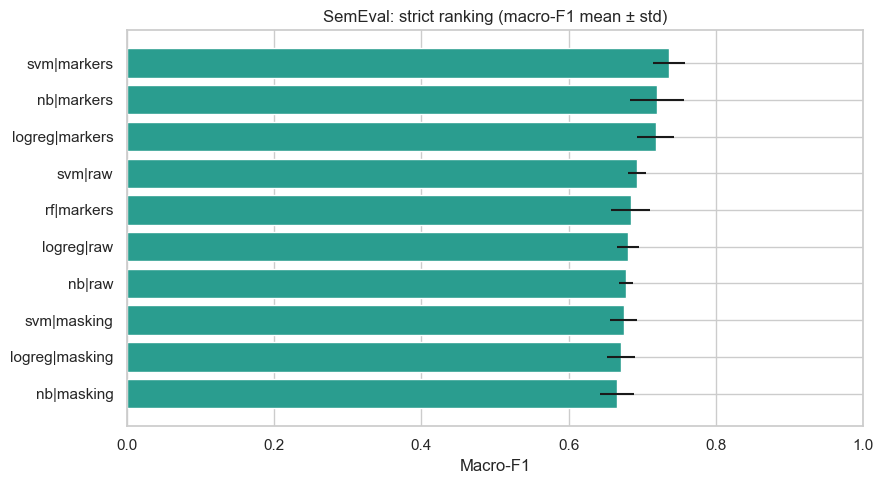

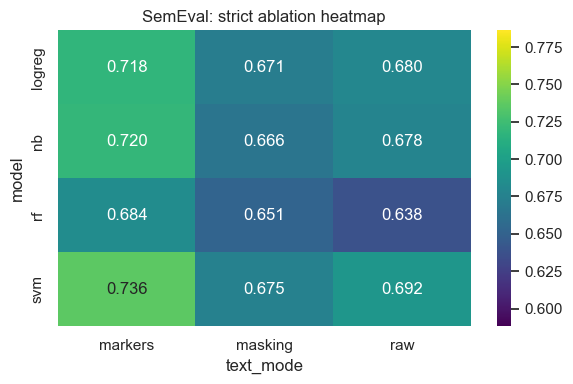

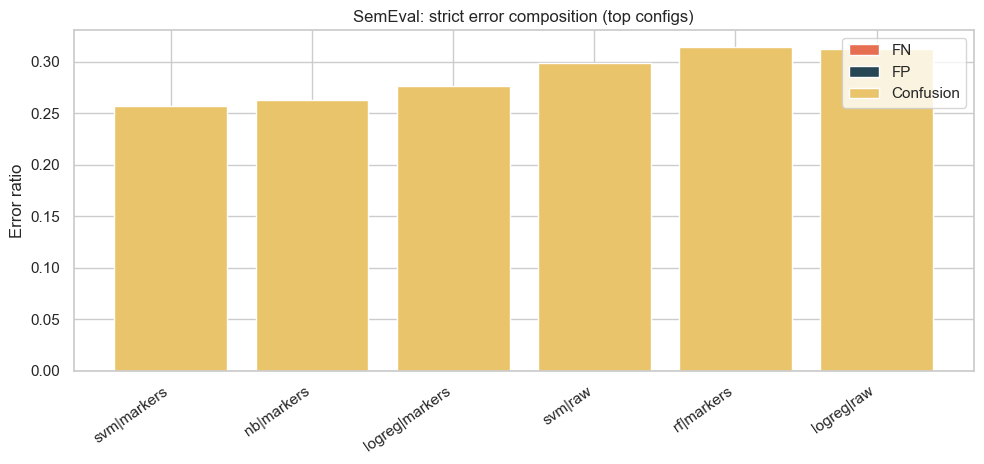

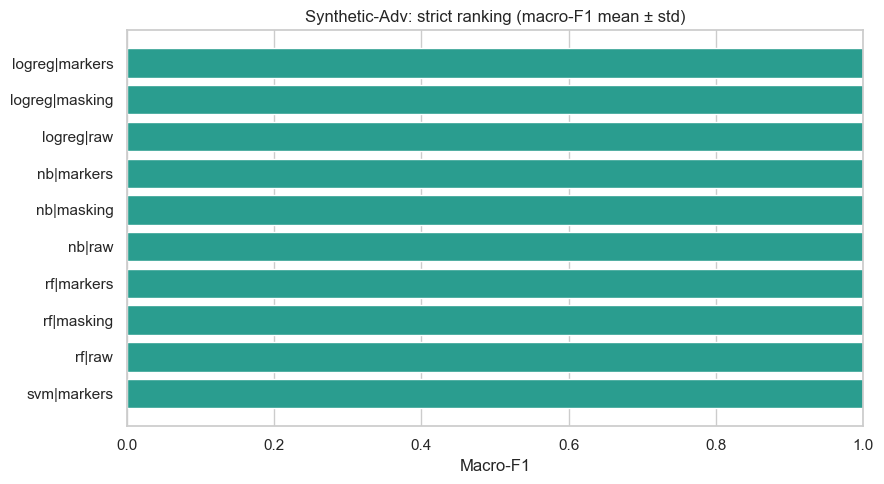

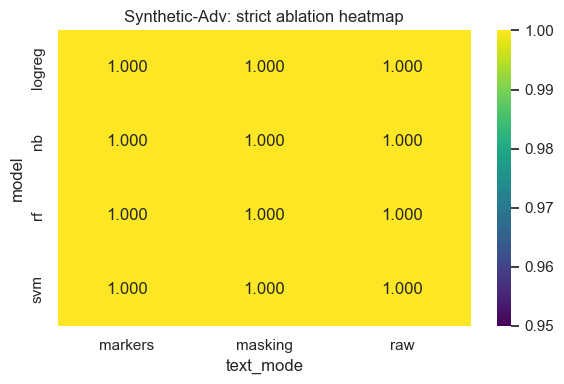

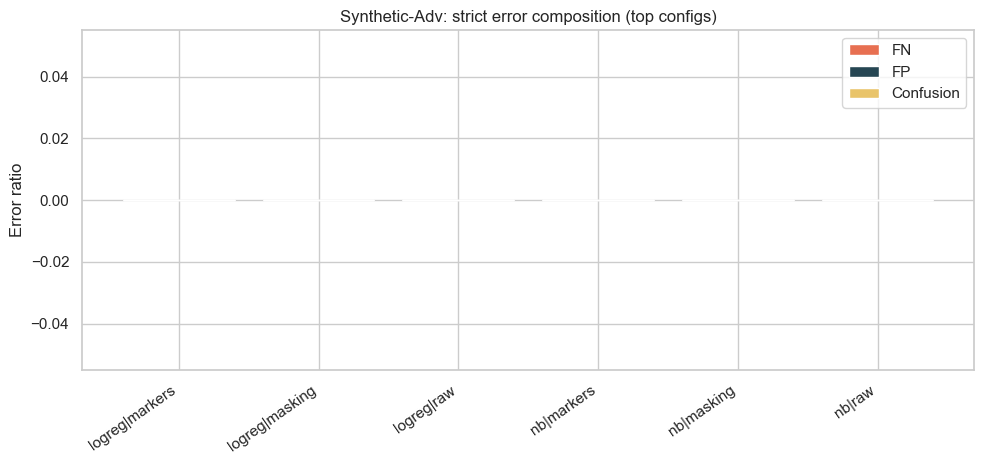

In [14]:
for ds_name in strict_summary["dataset"].unique():
    sub = strict_summary[strict_summary["dataset"] == ds_name].copy()

    top = sub.head(10)
    plt.figure(figsize=(9, 5))
    y = top["model"] + "|" + top["text_mode"]
    plt.barh(
        y, top["f1_macro_mean"], xerr=top["f1_macro_std"].fillna(0.0), color="#2A9D8F"
    )
    plt.gca().invert_yaxis()
    plt.xlim(0, 1)
    plt.title(f"{ds_name}: strict ranking (macro-F1 mean ± std)")
    plt.xlabel("Macro-F1")
    plt.tight_layout()
    plt.show()

    pv = sub.pivot_table(
        index="model", columns="text_mode", values="f1_macro_mean", aggfunc="mean"
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        pv,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=max(0, pv.min().min() - 0.05),
        vmax=min(1, pv.max().max() + 0.05),
    )
    plt.title(f"{ds_name}: strict ablation heatmap")
    plt.tight_layout()
    plt.show()

    top_e = sub.head(6).copy()
    top_e["label"] = top_e["model"] + "|" + top_e["text_mode"]
    x = np.arange(len(top_e))
    plt.figure(figsize=(10, 4.8))
    plt.bar(x, top_e["fn_mean"], color="#E76F51", label="FN")
    plt.bar(x, top_e["fp_mean"], bottom=top_e["fn_mean"], color="#264653", label="FP")
    plt.bar(
        x,
        top_e["conf_mean"],
        bottom=top_e["fn_mean"] + top_e["fp_mean"],
        color="#E9C46A",
        label="Confusion",
    )
    plt.xticks(x, top_e["label"], rotation=35, ha="right")
    plt.ylabel("Error ratio")
    plt.title(f"{ds_name}: strict error composition (top configs)")
    plt.legend()
    plt.tight_layout()
    plt.show()

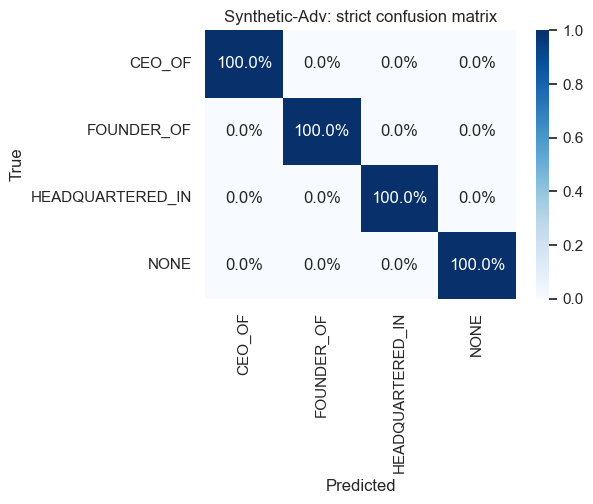

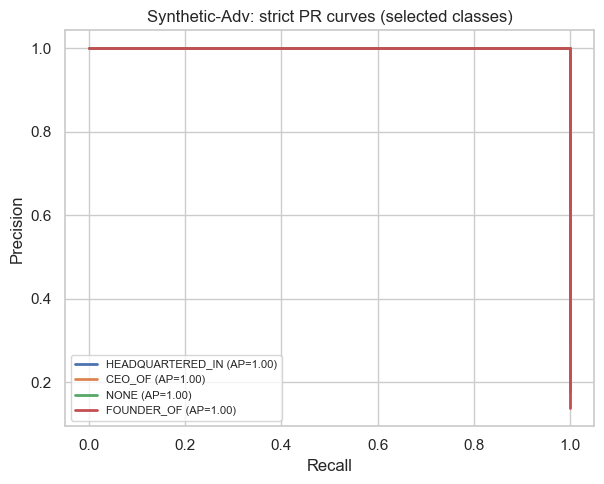

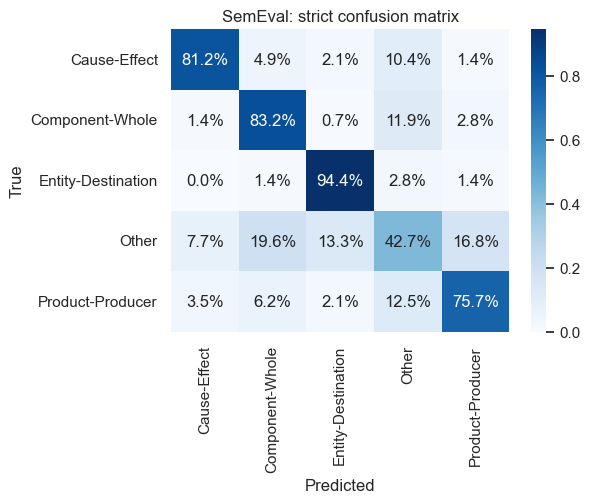

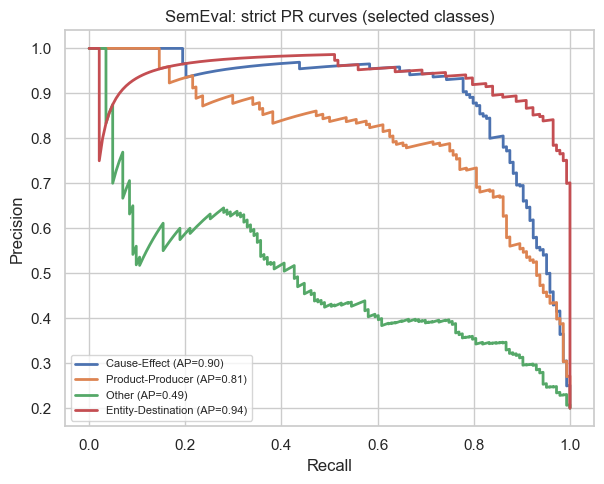

In [15]:
def show_best_curves(df_source, ds_name, leakage_safe):
    best = strict_summary[strict_summary["dataset"] == ds_name].iloc[0]
    te, pred, prob, labels, _, split_note = train_classical_model_strict(
        df_source,
        model_key=best["model"],
        text_mode=best["text_mode"],
        seed=SEED,
        leakage_safe=leakage_safe,
    )

    cm = confusion_matrix(te["relation"], pred, labels=labels)
    with np.errstate(divide="ignore", invalid="ignore"):
        cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cmn = np.nan_to_num(cmn)

    plt.figure(figsize=(6.2, 5.2))
    sns.heatmap(
        cmn, annot=True, fmt=".1%", cmap="Blues", xticklabels=labels, yticklabels=labels
    )
    plt.title(f"{ds_name}: strict confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    support = te["relation"].value_counts()
    chosen = [c for c in support.index[:4] if c in labels]
    y_true_idx = pd.Categorical(te["relation"], categories=labels).codes
    y_true_bin = label_binarize(y_true_idx, classes=np.arange(len(labels)))

    plt.figure(figsize=(6.2, 5.0))
    for c in chosen:
        i = labels.index(c)
        p, r, _ = precision_recall_curve(y_true_bin[:, i], prob[:, i])
        ap = average_precision_score(y_true_bin[:, i], prob[:, i])
        plt.plot(r, p, lw=2.0, label=f"{c} (AP={ap:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ds_name}: strict PR curves (selected classes)")
    plt.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.show()


show_best_curves(synthetic_df, "Synthetic-Adv", leakage_safe=True)
if semeval_df is not None:
    show_best_curves(semeval_df, "SemEval", leakage_safe=False)

In [16]:
qc = strict_df.copy()
qc_flags = []

qc_flags.append(qc[qc["f1_macro"] >= 0.995].assign(flag="f1_near_1"))
qc_flags.append(qc[qc["mcc"] >= 0.995].assign(flag="mcc_near_1"))

qc_flags.append(
    qc[(qc["roc_auc_ovr_macro"] >= 0.90) & (qc["f1_macro"] <= 0.60)].assign(
        flag="high_auc_low_f1"
    )
)

qc_report = (
    pd.concat([x for x in qc_flags if len(x) > 0], ignore_index=True)
    if any(len(x) > 0 for x in qc_flags)
    else pd.DataFrame()
)

if len(qc_report) > 0:
    display(
        qc_report[
            [
                "dataset",
                "seed",
                "model",
                "text_mode",
                "f1_macro",
                "mcc",
                "roc_auc_ovr_macro",
                "pr_auc_macro",
                "flag",
            ]
        ].sort_values(["dataset", "flag"])
    )

final_report_table = strict_summary[
    [
        "dataset",
        "model",
        "text_mode",
        "split_note",
        "f1_macro_mean",
        "f1_macro_std",
        "mcc_mean",
        "pr_auc_mean",
        "roc_auc_mean",
        "fn_mean",
        "fp_mean",
        "conf_mean",
    ]
].copy()
display(final_report_table.head(20))

,dataset,seed,model,text_mode,f1_macro,mcc,roc_auc_ovr_macro,pr_auc_macro,flag
0,Synthetic-Adv,11,logreg,raw,1.0,1.0,1.0,1.0,f1_near_1
1,Synthetic-Adv,11,logreg,masking,1.0,1.0,1.0,1.0,f1_near_1
2,Synthetic-Adv,11,logreg,markers,1.0,1.0,1.0,1.0,f1_near_1
3,Synthetic-Adv,11,svm,raw,1.0,1.0,1.0,1.0,f1_near_1
4,Synthetic-Adv,11,svm,masking,1.0,1.0,1.0,1.0,f1_near_1
...,...,...,...,...,...,...,...,...,...
67,Synthetic-Adv,77,nb,masking,1.0,1.0,1.0,1.0,mcc_near_1
68,Synthetic-Adv,77,nb,markers,1.0,1.0,1.0,1.0,mcc_near_1
69,Synthetic-Adv,77,rf,raw,1.0,1.0,1.0,1.0,mcc_near_1
70,Synthetic-Adv,77,rf,masking,1.0,1.0,1.0,1.0,mcc_near_1


,dataset,model,text_mode,split_note,f1_macro_mean,f1_macro_std,mcc_mean,pr_auc_mean,roc_auc_mean,fn_mean,fp_mean,conf_mean
0,SemEval,svm,markers,stratified_random_split,0.736178,0.022314,0.679083,0.788423,0.922851,0.0,0.0,0.257555
1,SemEval,nb,markers,stratified_random_split,0.719576,0.036497,0.676096,0.780056,0.920696,0.0,0.0,0.262669
2,SemEval,logreg,markers,stratified_random_split,0.717966,0.025363,0.655359,0.771524,0.917215,0.0,0.0,0.276616
3,SemEval,svm,raw,stratified_random_split,0.692495,0.012520,0.629210,0.750675,0.906214,0.0,0.0,0.298466
4,SemEval,rf,markers,stratified_random_split,0.684153,0.026464,0.608107,0.734909,0.896367,0.0,0.0,0.314737
5,SemEval,logreg,raw,stratified_random_split,0.680138,0.015167,0.611804,0.733448,0.900999,0.0,0.0,0.312413
6,SemEval,nb,raw,stratified_random_split,0.677847,0.009268,0.621192,0.739055,0.902041,0.0,0.0,0.306834
7,SemEval,svm,masking,stratified_random_split,0.674842,0.018568,0.609943,0.736429,0.898596,0.0,0.0,0.313808
8,SemEval,logreg,masking,stratified_random_split,0.671042,0.018483,0.598071,0.724462,0.895945,0.0,0.0,0.322641
9,SemEval,nb,masking,stratified_random_split,0.665573,0.022862,0.612091,0.722844,0.896822,0.0,0.0,0.314272


## 6) Extended Experiments

### 6.1) Experiment Grid

In [17]:
experiment_grid = pd.DataFrame(
    [
        {
            "exp_id": "E01",
            "dataset": "Synthetic-Hard",
            "input": "raw entities",
            "model": "Dependency Rules",
            "goal": "High precision, low recall baseline",
        },
        {
            "exp_id": "E02",
            "dataset": "Synthetic-Hard",
            "input": "raw entities",
            "model": "OpenIE-style Heuristic",
            "goal": "Boundary error analysis",
        },
        {
            "exp_id": "E03",
            "dataset": "Synthetic-Hard",
            "input": "[ENT1]/[ENT2] masking",
            "model": "TF-IDF + LogisticRegression",
            "goal": "Lightweight supervised baseline",
        },
        {
            "exp_id": "E04",
            "dataset": "SemEval-2010 (subset)",
            "input": "[ENT1]/[ENT2] masking",
            "model": "TF-IDF + LogisticRegression",
            "goal": "Real-data baseline",
        },
        {
            "exp_id": "E05",
            "dataset": "SemEval-2010 (subset)",
            "input": "entity markers [E1]/[E2]",
            "model": "SentenceTransformer + PyTorch head",
            "goal": "Strong neural baseline",
        },
        {
            "exp_id": "E06",
            "dataset": "Re-TACRED (optional)",
            "input": "entity markers [E1]/[E2]",
            "model": "SentenceTransformer + PyTorch head",
            "goal": "Stress test on noisy/imbalanced data",
        },
    ]
)
experiment_grid

,exp_id,dataset,input,model,goal
0,E01,Synthetic-Hard,raw entities,Dependency Rules,"High precision, low recall baseline"
1,E02,Synthetic-Hard,raw entities,OpenIE-style Heuristic,Boundary error analysis
2,E03,Synthetic-Hard,[ENT1]/[ENT2] masking,TF-IDF + LogisticRegression,Lightweight supervised baseline
3,E04,SemEval-2010 (subset),[ENT1]/[ENT2] masking,TF-IDF + LogisticRegression,Real-data baseline
4,E05,SemEval-2010 (subset),entity markers [E1]/[E2],SentenceTransformer + PyTorch head,Strong neural baseline
5,E06,Re-TACRED (optional),entity markers [E1]/[E2],SentenceTransformer + PyTorch head,Stress test on noisy/imbalanced data


### 6.2) Synthetic Baselines

In [18]:
syn = synthetic_df.copy()

rule_preds = syn.apply(
    lambda r: predict_dependency_rule(r["sentence"], r["e1"], r["e2"]), axis=1
)
openie_out = syn.apply(
    lambda r: predict_openie_style(r["sentence"], r["e1"], r["e2"]), axis=1
)
openie_preds = [x[0] for x in openie_out]
openie_boundary_rate = float(np.mean([x[1] for x in openie_out]))

labels_syn = sorted(syn["relation"].unique().tolist())


def onehot_probs(preds, labels):
    le = LabelEncoder().fit(labels)
    idx = le.transform(preds)
    probs = np.zeros((len(preds), len(labels)))
    probs[np.arange(len(preds)), idx] = 1.0
    return probs, list(le.classes_)


rule_probs, rule_labels = onehot_probs(rule_preds, labels_syn)
openie_probs, openie_labels = onehot_probs(openie_preds, labels_syn)

res_rule = evaluate_multiclass(syn["relation"], rule_preds, rule_probs, rule_labels)
res_openie = evaluate_multiclass(
    syn["relation"], openie_preds, openie_probs, openie_labels
)

syn_test_lr, syn_pred_lr, syn_prob_lr, syn_labels_lr, _ = train_tfidf_logreg(
    syn, text_mode="masking", seed=SEED
)
res_lr = evaluate_multiclass(
    syn_test_lr["relation"], syn_pred_lr, syn_prob_lr, syn_labels_lr
)

try:
    syn_test_nn, syn_pred_nn, syn_prob_nn, syn_labels_nn, _ = train_sbert_torchhead(
        syn,
        text_mode="markers",
        model_name="sentence-transformers/all-mpnet-base-v2",
        epochs=8,
        seed=SEED,
    )
    res_nn = evaluate_multiclass(
        syn_test_nn["relation"], syn_pred_nn, syn_prob_nn, syn_labels_nn
    )
except Exception:
    syn_test_nn, syn_pred_nn, syn_prob_nn, syn_labels_nn, res_nn = (
        None,
        None,
        None,
        None,
        None,
    )

summary_syn = pd.DataFrame(
    [
        {"model": "Dependency Rules", **res_rule, "boundary_error_rate": np.nan},
        {
            "model": "OpenIE-style",
            **res_openie,
            "boundary_error_rate": openie_boundary_rate,
        },
        {"model": "TF-IDF + LR", **res_lr, "boundary_error_rate": np.nan},
        *(
            [{"model": "SBERT + TorchHead", **res_nn, "boundary_error_rate": np.nan}]
            if res_nn is not None
            else []
        ),
    ]
)
summary_syn.sort_values("f1_macro", ascending=False)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8718.15it/s]


,model,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,mcc,balanced_acc,cohen_kappa,roc_auc_ovr_macro,pr_auc_macro,boundary_error_rate
2,TF-IDF + LR,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,NaN
3,SBERT + TorchHead,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000,1.0000,1.000000,1.000000,1.000000,NaN
1,OpenIE-style,0.746735,0.7475,0.746735,0.746056,0.7475,0.663365,0.7475,0.663333,0.831667,0.653659,0.08125
0,Dependency Rules,0.715676,0.7525,0.715676,0.715439,0.7525,0.682070,0.7525,0.670000,0.835000,0.636128,NaN


### 6.3) SemEval Baselines and Embedder Comparison

In [19]:
if semeval_df is not None:
    sem = semeval_df.copy()

    sem_test_lr, sem_pred_lr, sem_prob_lr, sem_labels_lr, _ = train_tfidf_logreg(
        sem, text_mode="masking", seed=SEED
    )
    sem_res_lr = evaluate_multiclass(
        sem_test_lr["relation"], sem_pred_lr, sem_prob_lr, sem_labels_lr
    )

    sem_rows = [{"model": "SemEval: TF-IDF + LR", **sem_res_lr}]
    sem_nn_artifacts = {}

    embedder_candidates = [
        "sentence-transformers/all-MiniLM-L6-v2",
        "sentence-transformers/all-mpnet-base-v2",
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    ]

    for emb_name in embedder_candidates:
        try:
            tdf, pred, prob, labels = train_sbert_torchhead(
                sem,
                text_mode="markers",
                model_name=emb_name,
                epochs=6,
                seed=SEED,
            )
            met = evaluate_multiclass(tdf["relation"], pred, prob, labels)
            sem_rows.append(
                {"model": f"SemEval: SBERT + TorchHead [{emb_name}]", **met}
            )
            sem_nn_artifacts[emb_name] = (tdf, pred, prob, labels)
        except Exception:
            pass

    sem_summary = pd.DataFrame(sem_rows).sort_values("f1_macro", ascending=False)
    display(sem_summary)
else:
    sem_summary = pd.DataFrame()
    sem_nn_artifacts = {}

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8336.08it/s]


,model,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,mcc,balanced_acc,cohen_kappa,roc_auc_ovr_macro,pr_auc_macro
0,SemEval: TF-IDF + LR,0.678074,0.688982,0.678225,0.676843,0.688879,0.613906,0.688879,0.61123,0.895095,0.715911


### 6.3.1) E06 Optional: Re-TACRED Test

In [20]:
def load_retacred_subset(seed=42, max_classes=12, max_per_class=220):
    candidates = [
        ("DFKI-SLT/re-tacred", None),
        ("re-tacred", None),
        ("DFKI-SLT/tacred", None),
    ]

    ds = None
    used_source = None
    for name, cfg in candidates:
        try:
            ds = (
                load_dataset(name, cfg, split="train")
                if cfg
                else load_dataset(name, split="train")
            )
            used_source = name
            break
        except Exception:
            continue

    if ds is None:
        raise RuntimeError("Re-TACRED dataset is unavailable in this environment.")

    rows = []
    for item in ds:
        tokens = item.get("token") or item.get("tokens") or item.get("sentence")
        if isinstance(tokens, str):
            tokens = tokens.split()
        if not tokens:
            continue

        relation = item.get("relation") or item.get("label")
        if relation is None:
            continue

        subj_start = (
            item.get("subj_start")
            if "subj_start" in item
            else item.get("subject_start")
        )
        subj_end = (
            item.get("subj_end") if "subj_end" in item else item.get("subject_end")
        )
        obj_start = (
            item.get("obj_start") if "obj_start" in item else item.get("object_start")
        )
        obj_end = item.get("obj_end") if "obj_end" in item else item.get("object_end")

        if None in [subj_start, subj_end, obj_start, obj_end]:
            continue

        if not (
            0 <= subj_start <= subj_end < len(tokens)
            and 0 <= obj_start <= obj_end < len(tokens)
        ):
            continue

        e1 = " ".join(tokens[subj_start : subj_end + 1])
        e2 = " ".join(tokens[obj_start : obj_end + 1])
        sentence = " ".join(tokens)
        rows.append((sentence, e1, e2, relation))

    df = pd.DataFrame(rows, columns=["sentence", "e1", "e2", "relation"])
    if df.empty:
        raise RuntimeError("Re-TACRED parsed to an empty DataFrame.")

    counts = df["relation"].value_counts()
    keep = counts.head(max_classes).index
    df = df[df["relation"].isin(keep)].copy()

    # Keep the stress test lightweight but still class-diverse.
    df = (
        df.groupby("relation", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), max_per_class), random_state=seed))
        .reset_index(drop=True)
    )

    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df, used_source


e06_status = "not_run"
try:
    retacred_df, retacred_source = load_retacred_subset(seed=SEED)

    rt_test, rt_pred, rt_prob, rt_labels, _ = train_sbert_torchhead(
        retacred_df,
        text_mode="markers",
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        epochs=4,
        seed=SEED,
    )

    rt_metrics = evaluate_multiclass(rt_test["relation"], rt_pred, rt_prob, rt_labels)
    e06_result = pd.DataFrame(
        [
            {
                "exp_id": "E06",
                "status": "completed",
                "dataset": f"Re-TACRED ({retacred_source})",
                "model": "SentenceTransformer + PyTorch head",
                "text_mode": "markers",
                "rows_used": len(retacred_df),
                **rt_metrics,
            }
        ]
    )
    e06_status = "completed"
except Exception as e:
    e06_result = pd.DataFrame(
        [
            {
                "exp_id": "E06",
                "status": "skipped",
                "dataset": "Re-TACRED",
                "model": "SentenceTransformer + PyTorch head",
                "text_mode": "markers",
                "rows_used": 0,
                "reason": str(e),
            }
        ]
    )
    e06_status = "skipped"

display(e06_result)

if semeval_df is not None and len(sem_summary) > 0:
    sem_view = sem_summary[
        ["model", "f1_macro", "mcc", "pr_auc_macro", "roc_auc_ovr_macro"]
    ].copy()
    sem_view.insert(0, "exp_id", "E05")
    sem_view.insert(1, "status", "completed")
    sem_view.insert(2, "dataset", "SemEval-2010 (subset)")

    if e06_status == "completed":
        e06_view = e06_result[
            [
                "exp_id",
                "status",
                "dataset",
                "model",
                "f1_macro",
                "mcc",
                "pr_auc_macro",
                "roc_auc_ovr_macro",
            ]
        ].copy()
    else:
        e06_view = pd.DataFrame(
            [
                {
                    "exp_id": "E06",
                    "status": "skipped",
                    "dataset": "Re-TACRED",
                    "model": "SentenceTransformer + PyTorch head",
                    "f1_macro": np.nan,
                    "mcc": np.nan,
                    "pr_auc_macro": np.nan,
                    "roc_auc_ovr_macro": np.nan,
                }
            ]
        )

    e05_e06_overview = pd.concat([sem_view, e06_view], ignore_index=True)
    display(e05_e06_overview)
else:
    e05_e06_overview = e06_result.copy()

,exp_id,status,dataset,model,text_mode,rows_used,reason
0,E06,skipped,Re-TACRED,SentenceTransformer + PyTorch head,markers,0,Re-TACRED dataset is unavailable in this environment.


,exp_id,status,dataset,model,f1_macro,mcc,pr_auc_macro,roc_auc_ovr_macro
0,E05,completed,SemEval-2010 (subset),SemEval: TF-IDF + LR,0.678074,0.613906,0.715911,0.895095
1,E06,skipped,Re-TACRED,SentenceTransformer + PyTorch head,NaN,NaN,NaN,NaN


### 6.3.2) Additional Datasets

In [21]:
def build_synthetic_imbalanced(base_df, seed=42):
    parts = []
    target_frac = {
        "NONE": 0.55,
        "FOUNDER_OF": 0.20,
        "CEO_OF": 0.15,
        "HEADQUARTERED_IN": 0.10,
    }

    for rel, frac in target_frac.items():
        rel_df = base_df[base_df["relation"] == rel]
        n_take = max(30, int(len(base_df) * frac))
        n_take = min(n_take, len(rel_df))
        parts.append(rel_df.sample(n=n_take, random_state=seed))

    out = (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    return out


def build_synthetic_noisy(base_df, seed=42, noise_ratio=0.12):
    rng = np.random.default_rng(seed)
    out = base_df.copy().reset_index(drop=True)

    n_noise = int(len(out) * noise_ratio)
    noisy_idx = rng.choice(len(out), size=n_noise, replace=False)
    labels = out["relation"].unique().tolist()

    for idx in noisy_idx:
        cur = out.at[idx, "relation"]
        alternatives = [x for x in labels if x != cur]
        out.at[idx, "relation"] = rng.choice(alternatives)

    prefixes = ["Rumor:", "Unverified:", "Draft note:"]
    text_noise_idx = rng.choice(len(out), size=n_noise, replace=False)
    for idx in text_noise_idx:
        out.at[idx, "sentence"] = f"{rng.choice(prefixes)} {out.at[idx, 'sentence']}"

    return out.sample(frac=1, random_state=seed).reset_index(drop=True)


def dataset_profile(df, name):
    vc = df["relation"].value_counts()
    return {
        "dataset": name,
        "rows": len(df),
        "classes": vc.shape[0],
        "majority_class": vc.index[0],
        "imbalance_ratio_max_min": float(vc.max() / max(1, vc.min())),
    }


extra_datasets = {
    "Synthetic-Imbalanced": build_synthetic_imbalanced(synthetic_df, seed=SEED),
    "Synthetic-Noisy": build_synthetic_noisy(synthetic_df, seed=SEED, noise_ratio=0.12),
}

extra_dataset_profile_df = pd.DataFrame(
    [dataset_profile(df, name) for name, df in extra_datasets.items()]
)
display(extra_dataset_profile_df)

extra_runs = []
for ds_name, ds_df in extra_datasets.items():
    # Classical stress baseline.
    t0 = time.time()
    try:
        te, pred, prob, labels, _ = train_classical_model(
            ds_df, model_key="logreg", text_mode="markers", seed=SEED
        )
        met = evaluate_multiclass(te["relation"], pred, prob, labels)
        extra_runs.append(
            {
                "experiment": f"{ds_name} | TF-IDF+LR",
                "dataset": ds_name,
                "model": "TF-IDF + LR",
                "status": "completed",
                "runtime_sec": round(time.time() - t0, 2),
                "reason": "",
                **met,
            }
        )
    except Exception as e:
        extra_runs.append(
            {
                "experiment": f"{ds_name} | TF-IDF+LR",
                "dataset": ds_name,
                "model": "TF-IDF + LR",
                "status": "skipped",
                "runtime_sec": round(time.time() - t0, 2),
                "reason": str(e),
            }
        )

    # Neural stress baseline (compact epochs for iteration speed).
    t0 = time.time()
    try:
        te, pred, prob, labels, _ = train_sbert_torchhead(
            ds_df,
            text_mode="markers",
            model_name="sentence-transformers/all-MiniLM-L6-v2",
            epochs=4,
            seed=SEED,
        )
        met = evaluate_multiclass(te["relation"], pred, prob, labels)
        extra_runs.append(
            {
                "experiment": f"{ds_name} | SBERT+TorchHead",
                "dataset": ds_name,
                "model": "SBERT + TorchHead (MiniLM)",
                "status": "completed",
                "runtime_sec": round(time.time() - t0, 2),
                "reason": "",
                **met,
            }
        )
    except Exception as e:
        extra_runs.append(
            {
                "experiment": f"{ds_name} | SBERT+TorchHead",
                "dataset": ds_name,
                "model": "SBERT + TorchHead (MiniLM)",
                "status": "skipped",
                "runtime_sec": round(time.time() - t0, 2),
                "reason": str(e),
            }
        )

extra_experiments_df = pd.DataFrame(extra_runs)
for col in ["f1_macro", "mcc", "pr_auc_macro"]:
    if col not in extra_experiments_df.columns:
        extra_experiments_df[col] = np.nan

display(
    extra_experiments_df[
        [
            "experiment",
            "status",
            "runtime_sec",
            "reason",
            "f1_macro",
            "mcc",
            "pr_auc_macro",
        ]
    ]
)

completed_extra = extra_experiments_df[
    extra_experiments_df["status"] == "completed"
].copy()
if not completed_extra.empty:
    best_extra_by_dataset = (
        completed_extra.sort_values("f1_macro", ascending=False)
        .groupby("dataset", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    display(
        best_extra_by_dataset[
            ["dataset", "model", "f1_macro", "mcc", "pr_auc_macro", "runtime_sec"]
        ]
    )
else:
    best_extra_by_dataset = pd.DataFrame()

poster_takeaways = []
if not completed_extra.empty:
    top_row = completed_extra.sort_values("f1_macro", ascending=False).iloc[0]
    poster_takeaways.append(
        {
            "insight": "Best extra run",
            "value": f"{top_row['experiment']} (Macro-F1={top_row['f1_macro']:.3f}, MCC={top_row['mcc']:.3f})",
        }
    )

if "e06_result" in globals() and not e06_result.empty:
    poster_takeaways.append(
        {
            "insight": "E06 status",
            "value": f"{e06_result.iloc[0].get('status', 'unknown')} | {e06_result.iloc[0].get('reason', 'ok')}",
        }
    )

poster_takeaways.append(
    {
        "insight": "Poster-ready note",
        "value": "Use status+runtime+imbalance profile together with Macro-F1/MCC/PR-AUC in final comparison figure.",
    }
)

poster_takeaways_df = pd.DataFrame(poster_takeaways)
display(poster_takeaways_df)

,dataset,rows,classes,majority_class,imbalance_ratio_max_min
0,Synthetic-Imbalanced,1120,4,NONE,2.500000
1,Synthetic-Noisy,1600,4,HEADQUARTERED_IN,1.040712


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17433.25it/s]


,experiment,status,runtime_sec,reason,f1_macro,mcc,pr_auc_macro
0,Synthetic-Imbalanced | TF-IDF+LR,completed,0.03,,1.000000,1.000000,1.000000
1,Synthetic-Imbalanced | SBERT+TorchHead,completed,6.51,,0.994582,0.993874,1.000000
2,Synthetic-Noisy | TF-IDF+LR,completed,0.03,,0.896751,0.862719,0.832263
3,Synthetic-Noisy | SBERT+TorchHead,completed,6.38,,0.887223,0.850186,0.841048


,dataset,model,f1_macro,mcc,pr_auc_macro,runtime_sec
0,Synthetic-Imbalanced,TF-IDF + LR,1.000000,1.000000,1.000000,0.03
1,Synthetic-Noisy,TF-IDF + LR,0.896751,0.862719,0.832263,0.03


,insight,value
0,Best extra run,"Synthetic-Imbalanced | TF-IDF+LR (Macro-F1=1.000, MCC=1.000)"
1,E06 status,skipped | Re-TACRED dataset is unavailable in this environment.
2,Poster-ready note,Use status+runtime+imbalance profile together with Macro-F1/MCC/PR-AUC in final comparison figure.


### 6.3.3) External Datasets (from hugging face)

In [22]:
EXTERNAL_RE_CANDIDATES = [
    # RE benchmark (external and stable in this environment).
    {"name": "sem_eval_2010_task_8", "split": "train"},
    # External classification datasets used as stress-track proxies.
    {"name": "ag_news", "split": "train"},
    {"name": "dbpedia_14", "split": "train"},
    {"name": "yelp_polarity", "split": "train"},
]


def _safe_classlabel_to_name(ds, field_name, value):
    try:
        feat = ds.features.get(field_name)
        if hasattr(feat, "names") and isinstance(value, (int, np.integer)):
            names = feat.names
            if 0 <= int(value) < len(names):
                return names[int(value)]
    except Exception:
        pass
    return value


def _extract_tokens(item):
    if "token" in item and isinstance(item["token"], list):
        return item["token"]
    if "tokens" in item and isinstance(item["tokens"], list):
        return item["tokens"]

    sentence = (
        item.get("sentence")
        or item.get("text")
        or item.get("content")
        or item.get("sent")
    )
    if isinstance(sentence, str):
        return sentence.split()
    return None


def _extract_entity_spans(item):
    key_sets = [
        ("subj_start", "subj_end", "obj_start", "obj_end"),
        ("subject_start", "subject_end", "object_start", "object_end"),
        ("head_start", "head_end", "tail_start", "tail_end"),
    ]
    for ss, se, os_, oe in key_sets:
        if all(k in item for k in [ss, se, os_, oe]):
            return item[ss], item[se], item[os_], item[oe]

    # FewRel-like schema: h/t with nested position lists.
    if "h" in item and "t" in item:
        try:
            h_pos = item["h"][2][0]
            t_pos = item["t"][2][0]
            hs, he = int(h_pos[0]), int(h_pos[-1])
            ts, te = int(t_pos[0]), int(t_pos[-1])
            return hs, he, ts, te
        except Exception:
            return None

    return None


def load_external_relation_df(
    dataset_name, split="train", seed=42, max_classes=14, max_per_class=200
):
    ds = load_dataset(dataset_name, split=split)

    rows = []
    parse_mode = "strict_re"
    for item in ds:
        tokens = _extract_tokens(item)
        if not tokens:
            continue

        relation = item.get("relation", item.get("label", item.get("rel")))
        relation = _safe_classlabel_to_name(ds, "relation", relation)
        relation = _safe_classlabel_to_name(ds, "label", relation)
        if relation is None:
            continue

        spans = _extract_entity_spans(item)
        if spans is None:
            # Fallback: proxy entity-pair for non-RE datasets.
            parse_mode = "label_proxy"
            if len(tokens) == 1:
                e1_text, e2_text = tokens[0], tokens[0]
            else:
                e1_text, e2_text = tokens[0], tokens[-1]
            sentence = " ".join(tokens)
            rows.append((sentence, e1_text, e2_text, str(relation)))
            continue

        s1, e1, s2, e2 = [int(x) for x in spans]
        if not (0 <= s1 <= e1 < len(tokens) and 0 <= s2 <= e2 < len(tokens)):
            continue

        e1_text = " ".join(tokens[s1 : e1 + 1])
        e2_text = " ".join(tokens[s2 : e2 + 1])
        sentence = " ".join(tokens)

        rows.append((sentence, e1_text, e2_text, str(relation)))

    df = pd.DataFrame(rows, columns=["sentence", "e1", "e2", "relation"])
    if df.empty:
        raise RuntimeError("No parseable relation rows found for this dataset/schema.")

    counts = df["relation"].value_counts()
    keep = counts.head(max_classes).index
    df = df[df["relation"].isin(keep)].copy()
    df = (
        df.groupby("relation", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), max_per_class), random_state=seed))
        .reset_index(drop=True)
    )
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df, parse_mode


external_datasets = {}
external_catalog = []
for cand in EXTERNAL_RE_CANDIDATES:
    ds_name = cand["name"]
    split = cand["split"]
    key = f"{ds_name}:{split}"

    try:
        df, parse_mode = load_external_relation_df(ds_name, split=split, seed=SEED)
        external_datasets[key] = df
        vc = df["relation"].value_counts()
        external_catalog.append(
            {
                "dataset_key": key,
                "status": "loaded",
                "parse_mode": parse_mode,
                "rows": len(df),
                "classes": vc.shape[0],
                "imbalance_ratio_max_min": float(vc.max() / max(1, vc.min())),
                "reason": "",
            }
        )
    except Exception as e:
        external_catalog.append(
            {
                "dataset_key": key,
                "status": "skipped",
                "parse_mode": "n/a",
                "rows": 0,
                "classes": 0,
                "imbalance_ratio_max_min": np.nan,
                "reason": str(e),
            }
        )

external_catalog_df = pd.DataFrame(external_catalog)
display(external_catalog_df)

external_runs = []
for ds_key, ds_df in external_datasets.items():
    # Fast classical baseline.
    t0 = time.time()
    try:
        te, pred, prob, labels, _ = train_classical_model(
            ds_df, model_key="logreg", text_mode="markers", seed=SEED
        )
        met = evaluate_multiclass(te["relation"], pred, prob, labels)
        external_runs.append(
            {
                "dataset_key": ds_key,
                "model": "TF-IDF + LR",
                "status": "completed",
                "runtime_sec": round(time.time() - t0, 2),
                "reason": "",
                **met,
            }
        )
    except Exception as e:
        external_runs.append(
            {
                "dataset_key": ds_key,
                "model": "TF-IDF + LR",
                "status": "skipped",
                "runtime_sec": round(time.time() - t0, 2),
                "reason": str(e),
            }
        )

    # Compact neural run (skip extremely large sets for iteration speed).
    t0 = time.time()
    if len(ds_df) > 4000:
        external_runs.append(
            {
                "dataset_key": ds_key,
                "model": "SBERT + TorchHead (MiniLM)",
                "status": "skipped",
                "runtime_sec": 0.0,
                "reason": "dataset too large for compact notebook run",
            }
        )
    else:
        try:
            te, pred, prob, labels, _ = train_sbert_torchhead(
                ds_df,
                text_mode="markers",
                model_name="sentence-transformers/all-MiniLM-L6-v2",
                epochs=4,
                seed=SEED,
            )
            met = evaluate_multiclass(te["relation"], pred, prob, labels)
            external_runs.append(
                {
                    "dataset_key": ds_key,
                    "model": "SBERT + TorchHead (MiniLM)",
                    "status": "completed",
                    "runtime_sec": round(time.time() - t0, 2),
                    "reason": "",
                    **met,
                }
            )
        except Exception as e:
            external_runs.append(
                {
                    "dataset_key": ds_key,
                    "model": "SBERT + TorchHead (MiniLM)",
                    "status": "skipped",
                    "runtime_sec": round(time.time() - t0, 2),
                    "reason": str(e),
                }
            )

external_result_cols = [
    "dataset_key",
    "model",
    "status",
    "runtime_sec",
    "reason",
    "f1_macro",
    "mcc",
    "pr_auc_macro",
    "roc_auc_ovr_macro",
]

# Keep a stable schema even when no external dataset loaded.
external_experiments_df = pd.DataFrame(external_runs, columns=external_result_cols)

display(external_experiments_df[external_result_cols])

external_completed = external_experiments_df[
    external_experiments_df["status"] == "completed"
].copy()
if not external_completed.empty:
    external_best_df = (
        external_completed.sort_values("f1_macro", ascending=False)
        .groupby("dataset_key", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    display(
        external_best_df[
            ["dataset_key", "model", "f1_macro", "mcc", "pr_auc_macro", "runtime_sec"]
        ]
    )
else:
    external_best_df = pd.DataFrame(
        columns=[
            "dataset_key",
            "model",
            "f1_macro",
            "mcc",
            "pr_auc_macro",
            "runtime_sec",
        ]
    )

external_skip_reasons_df = external_experiments_df[
    external_experiments_df["status"] == "skipped"
][["dataset_key", "model", "reason"]].copy()
if not external_skip_reasons_df.empty:
    display(external_skip_reasons_df)

,dataset_key,status,parse_mode,rows,classes,imbalance_ratio_max_min,reason
0,sem_eval_2010_task_8:train,loaded,label_proxy,2766,14,1.204819,
1,ag_news:train,loaded,label_proxy,800,4,1.000000,
2,dbpedia_14:train,loaded,label_proxy,2800,14,1.000000,
3,yelp_polarity:train,loaded,label_proxy,400,2,1.000000,


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17978.83it/s]


,dataset_key,model,status,runtime_sec,reason,f1_macro,mcc,pr_auc_macro,roc_auc_ovr_macro
0,sem_eval_2010_task_8:train,TF-IDF + LR,completed,0.26,,0.630405,0.617865,0.648756,0.918747
1,sem_eval_2010_task_8:train,SBERT + TorchHead (MiniLM),completed,10.70,,0.374154,0.358187,0.418430,0.849469
2,ag_news:train,TF-IDF + LR,completed,0.05,,0.773220,0.702014,0.854890,0.935052
3,ag_news:train,SBERT + TorchHead (MiniLM),completed,7.53,,0.849025,0.800292,0.911059,0.966510
4,dbpedia_14:train,TF-IDF + LR,completed,0.47,,0.926438,0.921423,0.969768,0.996913
5,dbpedia_14:train,SBERT + TorchHead (MiniLM),completed,12.96,,0.945616,0.942531,0.978878,0.997785
6,yelp_polarity:train,TF-IDF + LR,completed,0.06,,0.825000,0.650000,NaN,NaN
7,yelp_polarity:train,SBERT + TorchHead (MiniLM),completed,7.58,,0.800000,0.600000,NaN,NaN


,dataset_key,model,f1_macro,mcc,pr_auc_macro,runtime_sec
0,dbpedia_14:train,SBERT + TorchHead (MiniLM),0.945616,0.942531,0.978878,12.96
1,ag_news:train,SBERT + TorchHead (MiniLM),0.849025,0.800292,0.911059,7.53
2,yelp_polarity:train,TF-IDF + LR,0.825000,0.650000,NaN,0.06
3,sem_eval_2010_task_8:train,TF-IDF + LR,0.630405,0.617865,0.648756,0.26


### 6.4) Classical Ablation Grid

In [23]:
expanded_rows = []
CLASSICAL_MODELS = ["logreg", "svm", "nb", "rf"]
TEXT_MODES = ["raw", "masking", "markers"]

for tm in TEXT_MODES:
    for mk in CLASSICAL_MODELS:
        te, pred, prob, labels, _ = train_classical_model(
            synthetic_df, model_key=mk, text_mode=tm, seed=SEED
        )
        met = evaluate_multiclass(te["relation"], pred, prob, labels)
        tax = error_taxonomy(te["relation"], pred).to_dict()
        expanded_rows.append(
            {
                "dataset": "Synthetic",
                "family": "classical",
                "model_key": mk,
                "text_mode": tm,
                **met,
                "err_false_negative": tax.get("false_negative", 0.0),
                "err_false_positive": tax.get("false_positive", 0.0),
                "err_label_confusion": tax.get("label_confusion", 0.0),
            }
        )

if semeval_df is not None:
    for tm in TEXT_MODES:
        for mk in CLASSICAL_MODELS:
            te, pred, prob, labels, _ = train_classical_model(
                semeval_df, model_key=mk, text_mode=tm, seed=SEED
            )
            met = evaluate_multiclass(te["relation"], pred, prob, labels)
            tax = error_taxonomy(te["relation"], pred).to_dict()
            expanded_rows.append(
                {
                    "dataset": "SemEval",
                    "family": "classical",
                    "model_key": mk,
                    "text_mode": tm,
                    **met,
                    "err_false_negative": tax.get("false_negative", 0.0),
                    "err_false_positive": tax.get("false_positive", 0.0),
                    "err_label_confusion": tax.get("label_confusion", 0.0),
                }
            )

expanded_df = pd.DataFrame(expanded_rows)
expanded_df.sort_values(["dataset", "f1_macro"], ascending=[True, False]).head(20)

,dataset,family,model_key,text_mode,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,mcc,balanced_acc,cohen_kappa,roc_auc_ovr_macro,pr_auc_macro,err_false_negative,err_false_positive,err_label_confusion
21,SemEval,classical,svm,markers,0.747475,0.754533,0.747627,0.745975,0.754448,0.694596,0.754448,0.693174,0.925774,0.789325,0.0,0.0,0.245467
20,SemEval,classical,logreg,markers,0.723500,0.732218,0.723655,0.721836,0.732129,0.667140,0.732129,0.665280,0.916324,0.768327,0.0,0.0,0.267782
13,SemEval,classical,svm,raw,0.713184,0.723849,0.713309,0.712178,0.723786,0.657395,0.723786,0.654818,0.912642,0.769136,0.0,0.0,0.276151
22,SemEval,classical,nb,markers,0.711289,0.737796,0.711508,0.712909,0.737568,0.678926,0.737568,0.672228,0.920861,0.788781,0.0,0.0,0.262204
17,SemEval,classical,svm,masking,0.694922,0.708508,0.695069,0.693704,0.708392,0.638943,0.708392,0.635632,0.902372,0.736227,0.0,0.0,0.291492
12,SemEval,classical,logreg,raw,0.694461,0.702929,0.694580,0.695773,0.702894,0.631289,0.702894,0.628674,0.902779,0.741769,0.0,0.0,0.297071
14,SemEval,classical,nb,raw,0.694207,0.714086,0.694394,0.694836,0.713840,0.647331,0.713840,0.642580,0.905905,0.752702,0.0,0.0,0.285914
16,SemEval,classical,logreg,masking,0.678074,0.688982,0.678225,0.676843,0.688879,0.613906,0.688879,0.611230,0.895095,0.715911,0.0,0.0,0.311018
23,SemEval,classical,rf,markers,0.672290,0.673640,0.672364,0.679279,0.673728,0.593808,0.673728,0.592098,0.887862,0.705961,0.0,0.0,0.326360
18,SemEval,classical,nb,masking,0.637897,0.665272,0.637994,0.635961,0.665229,0.588051,0.665229,0.581587,0.896926,0.719935,0.0,0.0,0.334728


### 6.5) Diagnostic Visualizations

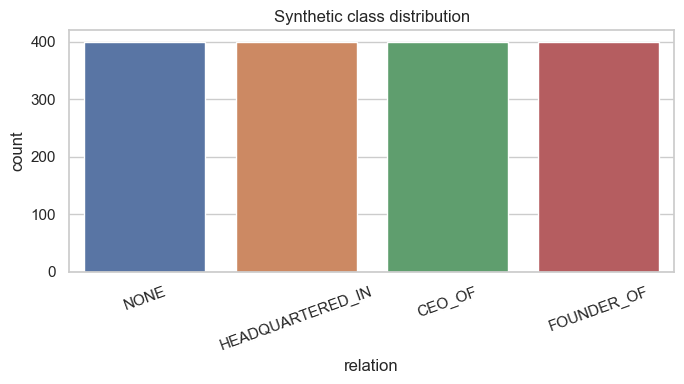

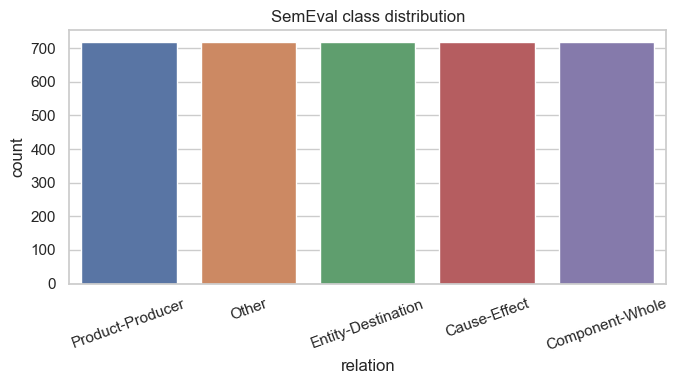

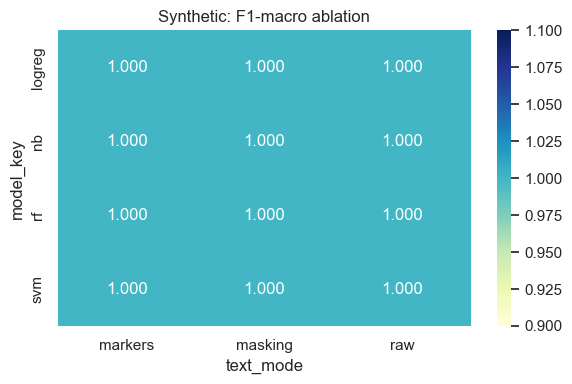

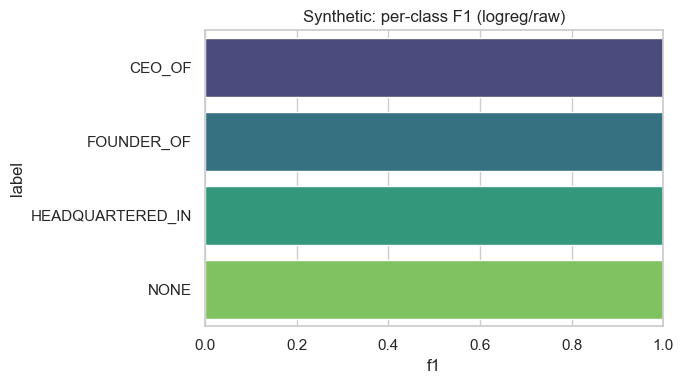

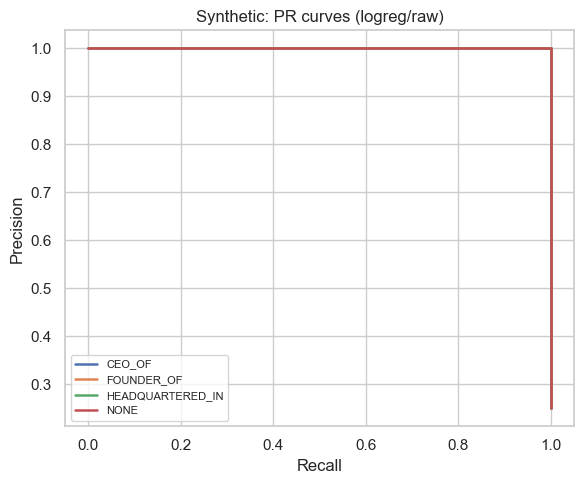

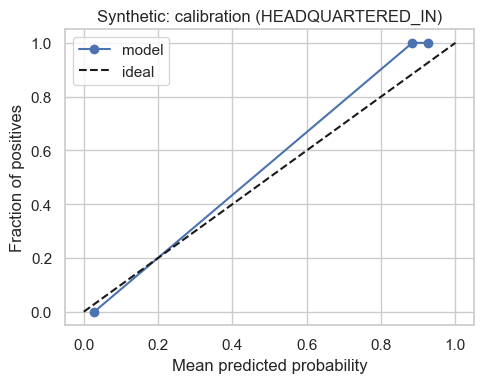

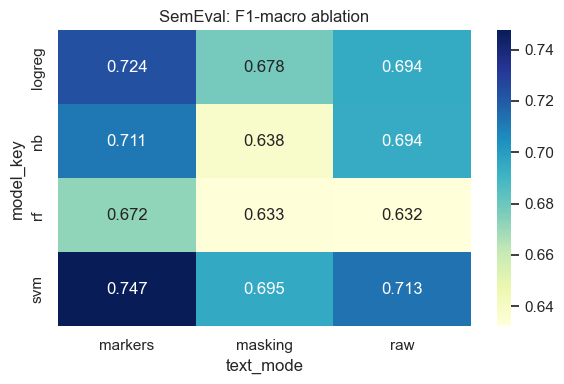

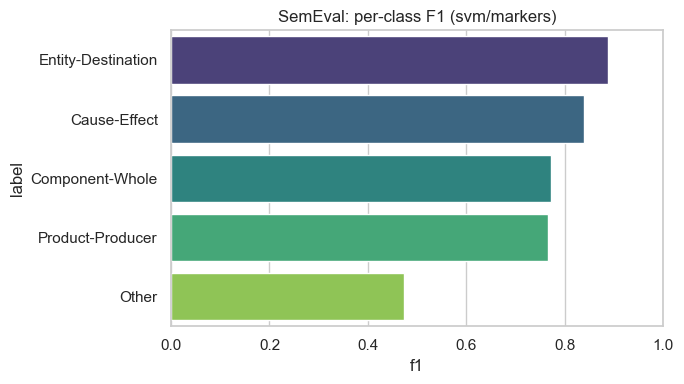

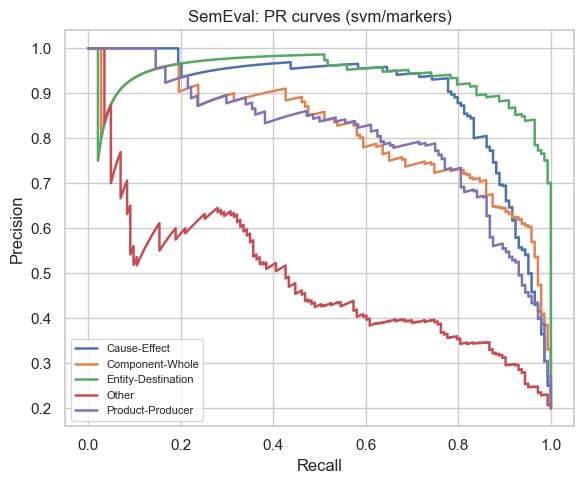

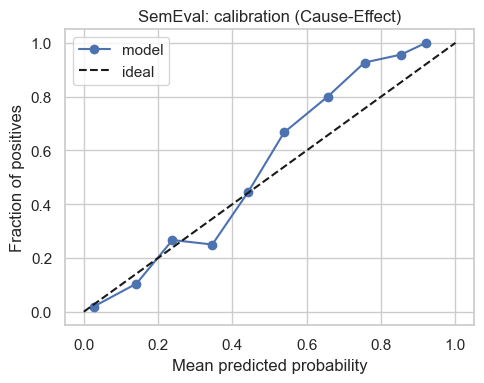

In [24]:
plot_dataset_distribution(synthetic_df, title="Synthetic class distribution")
if semeval_df is not None:
    plot_dataset_distribution(semeval_df, title="SemEval class distribution")

if len(expanded_df) > 0:
    for ds_name in expanded_df["dataset"].unique():
        sub = expanded_df[expanded_df["dataset"] == ds_name]
        pivot = sub.pivot_table(
            index="model_key", columns="text_mode", values="f1_macro", aggfunc="mean"
        )
        plt.figure(figsize=(6, 4))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
        plt.title(f"{ds_name}: F1-macro ablation")
        plt.tight_layout()
        plt.show()

        best = sub.sort_values("f1_macro", ascending=False).iloc[0]
        te, pred, prob, labels, _ = train_classical_model(
            synthetic_df if ds_name == "Synthetic" else semeval_df,
            model_key=best["model_key"],
            text_mode=best["text_mode"],
            seed=SEED,
        )
        plot_per_class_f1(
            te["relation"],
            pred,
            labels,
            title=f'{ds_name}: per-class F1 ({best["model_key"]}/{best["text_mode"]})',
        )
        plot_pr_curves(
            te["relation"],
            prob,
            labels,
            title=f'{ds_name}: PR curves ({best["model_key"]}/{best["text_mode"]})',
        )

        top_class = te["relation"].value_counts().index[0]
        y_true_bin = (te["relation"].values == top_class).astype(int)
        if top_class in labels:
            p_hat = prob[:, labels.index(top_class)]
            frac_pos, mean_pred = calibration_curve(y_true_bin, p_hat, n_bins=10)
            plt.figure(figsize=(5, 4))
            plt.plot(mean_pred, frac_pos, marker="o", label="model")
            plt.plot([0, 1], [0, 1], "k--", label="ideal")
            plt.title(f"{ds_name}: calibration ({top_class})")
            plt.xlabel("Mean predicted probability")
            plt.ylabel("Fraction of positives")
            plt.legend()
            plt.tight_layout()
            plt.show()

### 6.6) Confusion Matrices and ROC Curves

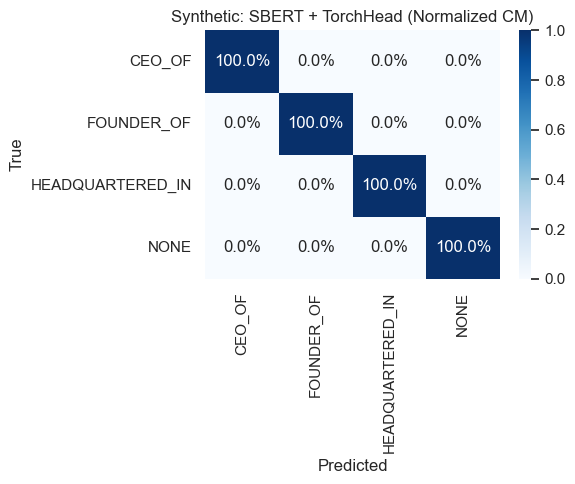

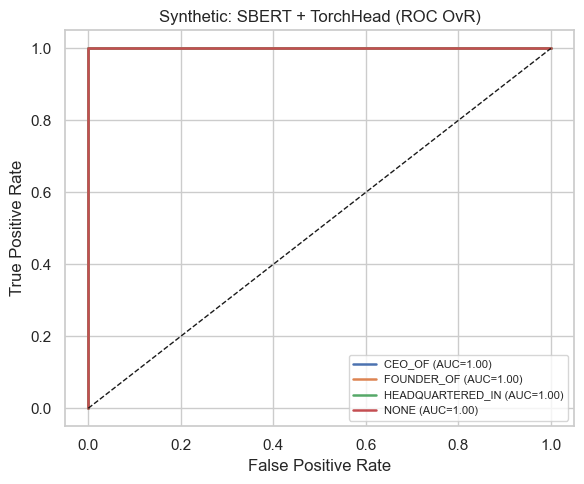

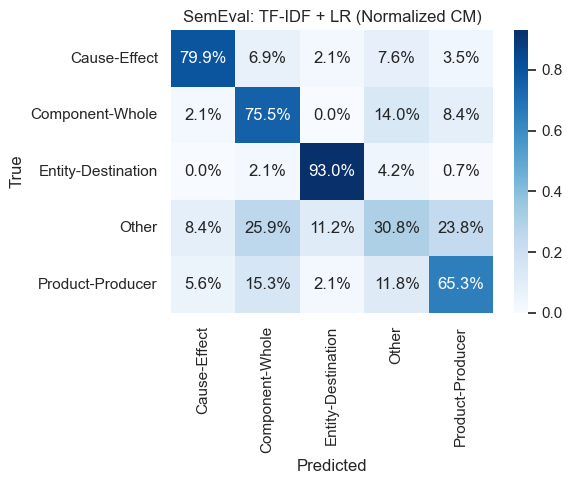

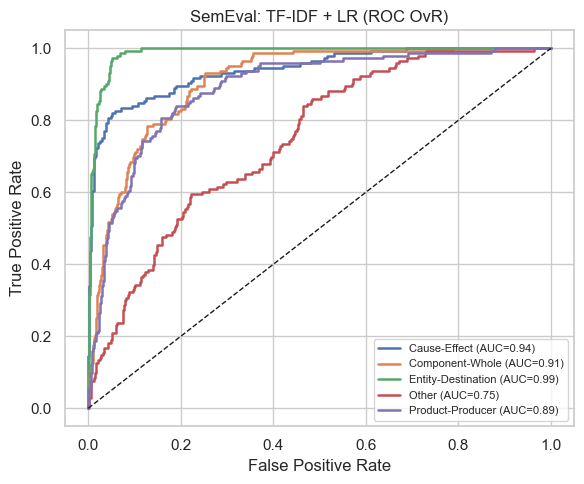

In [25]:
if syn_test_nn is not None:
    plot_confusion(
        syn_test_nn["relation"],
        syn_pred_nn,
        syn_labels_nn,
        title="Synthetic: SBERT + TorchHead (Normalized CM)",
    )
    plot_multiclass_roc(
        syn_test_nn["relation"],
        syn_prob_nn,
        syn_labels_nn,
        title="Synthetic: SBERT + TorchHead (ROC OvR)",
    )
else:
    plot_confusion(
        syn_test_lr["relation"],
        syn_pred_lr,
        syn_labels_lr,
        title="Synthetic: TF-IDF + LR (Normalized CM)",
    )
    plot_multiclass_roc(
        syn_test_lr["relation"],
        syn_prob_lr,
        syn_labels_lr,
        title="Synthetic: TF-IDF + LR (ROC OvR)",
    )

if semeval_df is not None:
    if len(sem_summary) > 0 and sem_summary.iloc[0]["model"].startswith(
        "SemEval: SBERT + TorchHead ["
    ):
        best_emb = sem_summary.iloc[0]["model"].split("[", 1)[1].rstrip("]")
        sem_best_test, sem_best_pred, sem_best_prob, sem_best_labels = sem_nn_artifacts[
            best_emb
        ]
        plot_confusion(
            sem_best_test["relation"],
            sem_best_pred,
            sem_best_labels,
            title=f"SemEval: Best Neural ({best_emb})",
        )
        plot_multiclass_roc(
            sem_best_test["relation"],
            sem_best_prob,
            sem_best_labels,
            title=f"SemEval: Best Neural ROC ({best_emb})",
        )
    else:
        plot_confusion(
            sem_test_lr["relation"],
            sem_pred_lr,
            sem_labels_lr,
            title="SemEval: TF-IDF + LR (Normalized CM)",
        )
        plot_multiclass_roc(
            sem_test_lr["relation"],
            sem_prob_lr,
            sem_labels_lr,
            title="SemEval: TF-IDF + LR (ROC OvR)",
        )

### 6.7) Embedding Space Visualization (UMAP)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6380.02it/s]


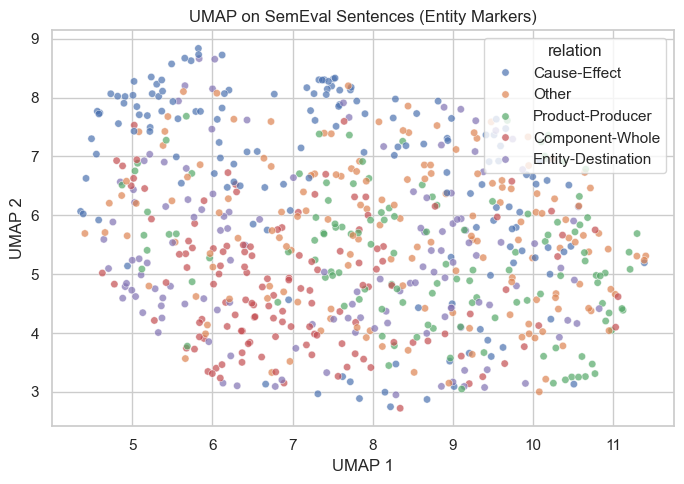

In [26]:
if semeval_df is not None:
    sample_vis = semeval_df.sample(
        n=min(700, len(semeval_df)), random_state=SEED
    ).copy()
    sample_vis["text"] = sample_vis.apply(add_entity_markers, axis=1)

    vis_encoder = SentenceTransformer(
        "sentence-transformers/all-mpnet-base-v2", device=str(DEVICE)
    )
    vis_vec = vis_encoder.encode(
        sample_vis["text"].tolist(), convert_to_numpy=True, show_progress_bar=False
    )

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.25, random_state=SEED)
    proj = reducer.fit_transform(vis_vec)

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        x=proj[:, 0], y=proj[:, 1], hue=sample_vis["relation"], s=28, alpha=0.7
    )
    plt.title("UMAP on SemEval Sentences (Entity Markers)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.tight_layout()
    plt.show()

### 6.8) KG Preview

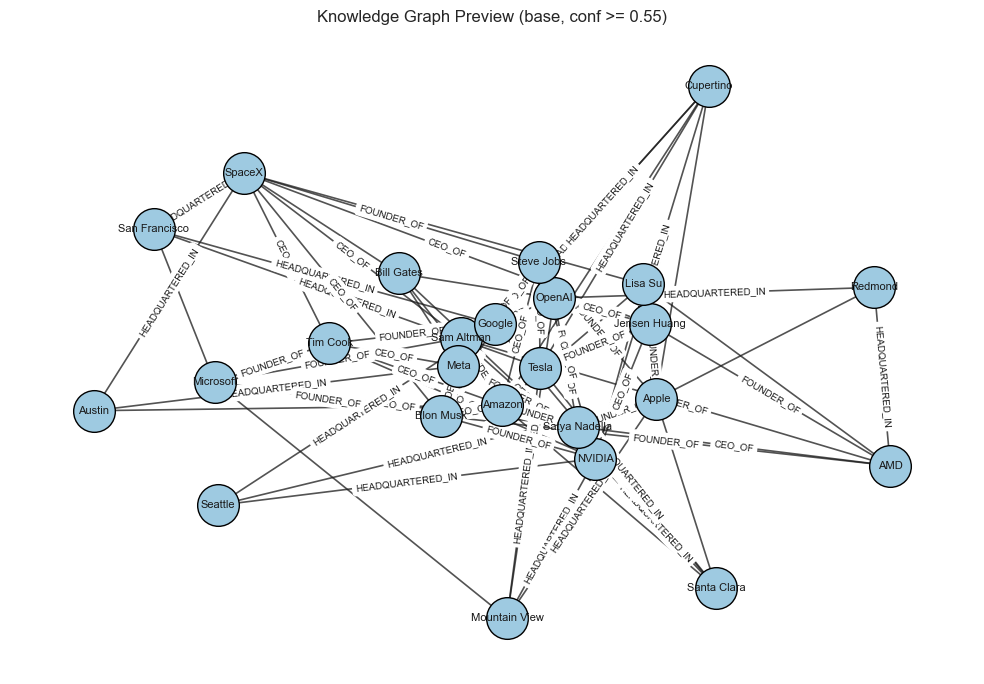

,edges_per_relation
pred_relation,
HEADQUARTERED_IN,80
FOUNDER_OF,80
CEO_OF,80


In [27]:
if (
    semeval_df is not None
    and len(sem_summary) > 0
    and sem_summary.iloc[0]["model"].startswith("SemEval: SBERT + TorchHead [")
):
    best_emb = sem_summary.iloc[0]["model"].split("[", 1)[1].rstrip("]")
    best_test_df, best_pred, best_prob, best_labels = sem_nn_artifacts[best_emb]

    kg_df = best_test_df[["e1", "e2"]].copy()
    kg_df["pred_relation"] = best_pred
    kg_df["confidence"] = best_prob.max(axis=1)
else:
    kg_df = syn_test_lr[["e1", "e2"]].copy()
    kg_df["pred_relation"] = syn_pred_lr
    kg_df["confidence"] = syn_prob_lr.max(axis=1)

kg_df = kg_df[~kg_df["pred_relation"].isin(["NONE", "Other"])].copy()


def build_triplets(df, min_conf=0.0, top_n=90):
    filtered = df[df["confidence"] >= min_conf].copy()
    triplets = [(r["e1"], r["pred_relation"], r["e2"]) for _, r in filtered.iterrows()]
    # Deduplicate while preserving insertion order.
    triplets = list(dict.fromkeys(triplets))
    return triplets[:top_n]


def plot_kg(triplets, title, node_color="#9ecae1", max_label_edges=60):
    if len(triplets) == 0:
        print(f"No triplets to render for: {title}")
        return

    G = nx.DiGraph()
    for h, rel, t in triplets:
        G.add_edge(h, t, relation=rel)

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(G, seed=SEED, k=0.9)
    nx.draw_networkx_nodes(
        G, pos, node_size=900, node_color=node_color, edgecolors="black"
    )
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, arrows=True, width=1.2, alpha=0.75)

    edge_labels = nx.get_edge_attributes(G, "relation")
    # Cap edge labels to avoid unreadable clutter.
    shown_edge_labels = dict(list(edge_labels.items())[:max_label_edges])
    nx.draw_networkx_edge_labels(G, pos, edge_labels=shown_edge_labels, font_size=7)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


base_triplets = build_triplets(kg_df, min_conf=0.55, top_n=90)
plot_kg(base_triplets, "Knowledge Graph Preview (base, conf >= 0.55)")

display(kg_df["pred_relation"].value_counts().rename("edges_per_relation").to_frame())

### 6.9) Alternative KG

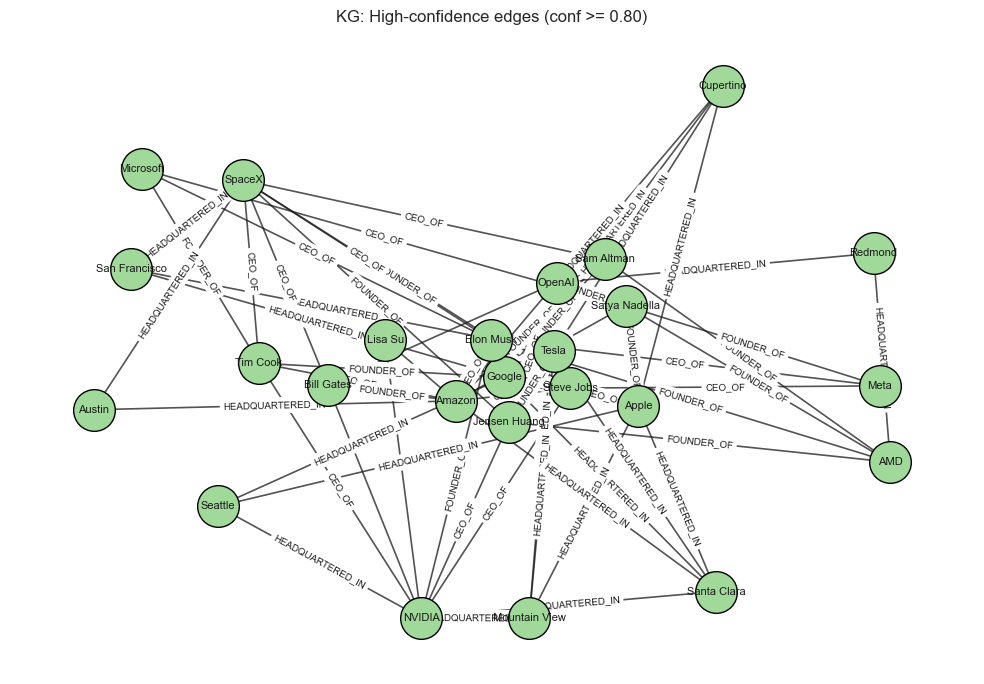

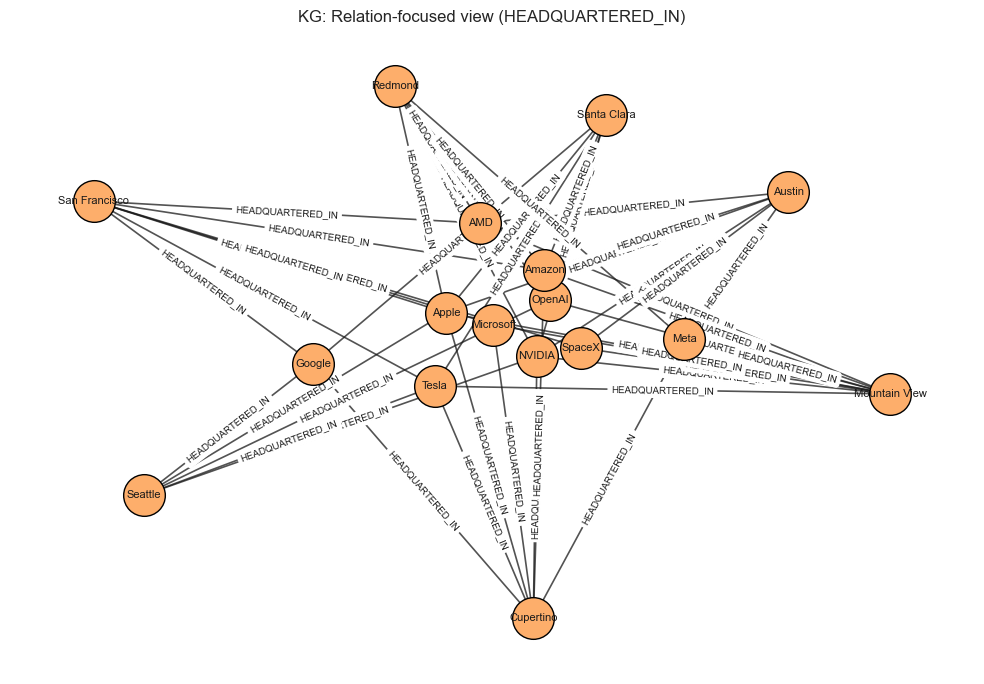

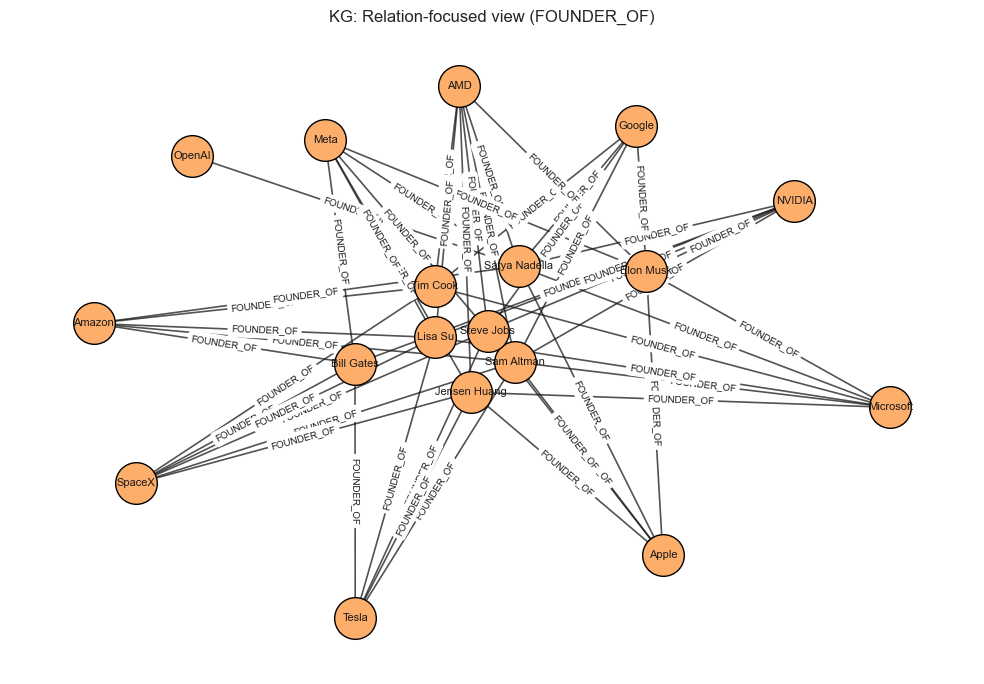

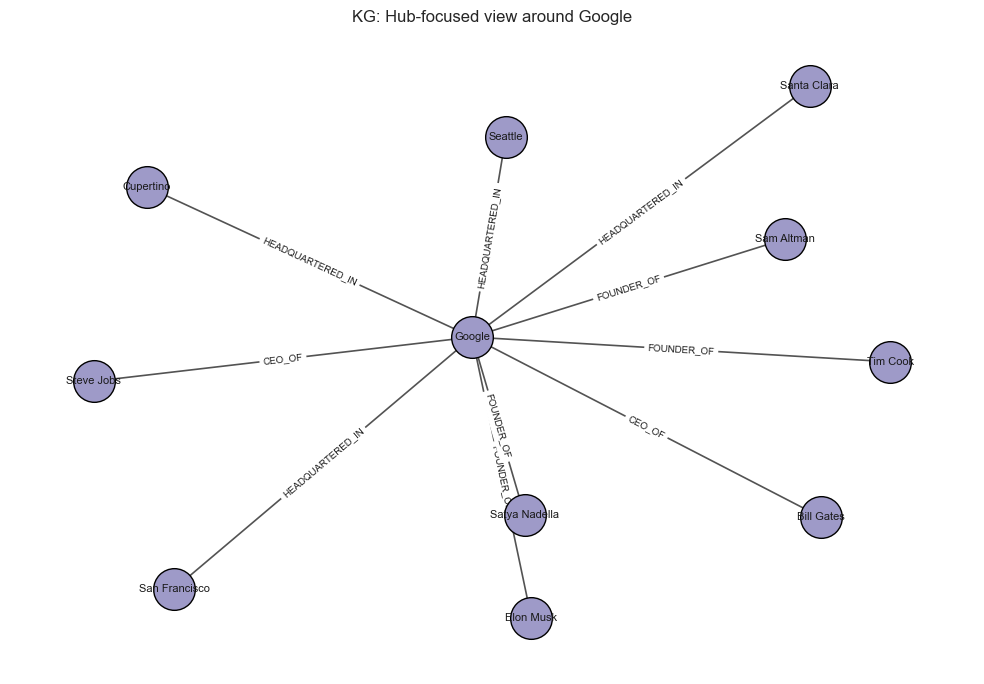

In [28]:
high_conf_triplets = build_triplets(kg_df, min_conf=0.80, top_n=70)
plot_kg(
    high_conf_triplets, "KG: High-confidence edges (conf >= 0.80)", node_color="#a1d99b"
)

relation_counts = kg_df["pred_relation"].value_counts()
if relation_counts.empty:
    print("No relation-focused KG views available.")
else:
    top_relations = relation_counts.head(2).index.tolist()
    for rel in top_relations:
        rel_triplets = build_triplets(
            kg_df[kg_df["pred_relation"] == rel], min_conf=0.55, top_n=60
        )
        plot_kg(
            rel_triplets, f"KG: Relation-focused view ({rel})", node_color="#fdae6b"
        )

entity_counts = pd.concat([kg_df["e1"], kg_df["e2"]]).value_counts()
if not entity_counts.empty:
    hub_entity = entity_counts.index[0]
    hub_df = kg_df[(kg_df["e1"] == hub_entity) | (kg_df["e2"] == hub_entity)].copy()
    hub_triplets = build_triplets(hub_df, min_conf=0.55, top_n=70)
    plot_kg(
        hub_triplets, f"KG: Hub-focused view around {hub_entity}", node_color="#9e9ac8"
    )
else:
    print("No entities available for hub-focused KG view.")

### 6.10) Output-Driven Insights

,text_mode,f1_macro,mcc,pr_auc_macro
0,markers,0.713638,0.658617,0.763099
2,raw,0.683538,0.620870,0.732362
1,masking,0.660954,0.598083,0.715037


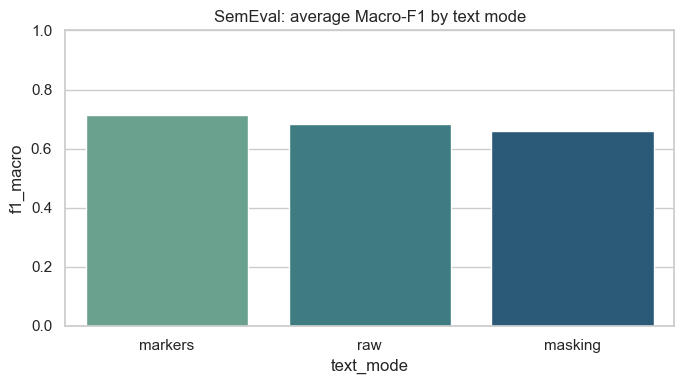

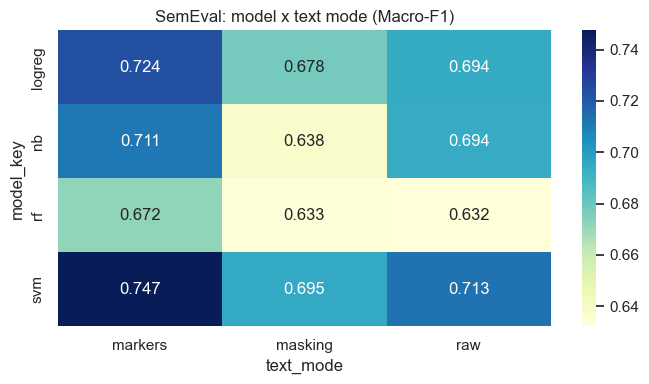

,model,text_mode,f1_macro_mean,f1_macro_std,mcc_mean,pr_auc_mean
0,svm,markers,0.736178,0.022314,0.679083,0.788423
1,nb,markers,0.719576,0.036497,0.676096,0.780056
2,logreg,markers,0.717966,0.025363,0.655359,0.771524
3,svm,raw,0.692495,0.012520,0.629210,0.750675
4,rf,markers,0.684153,0.026464,0.608107,0.734909
5,logreg,raw,0.680138,0.015167,0.611804,0.733448
6,nb,raw,0.677847,0.009268,0.621192,0.739055
7,svm,masking,0.674842,0.018568,0.609943,0.736429


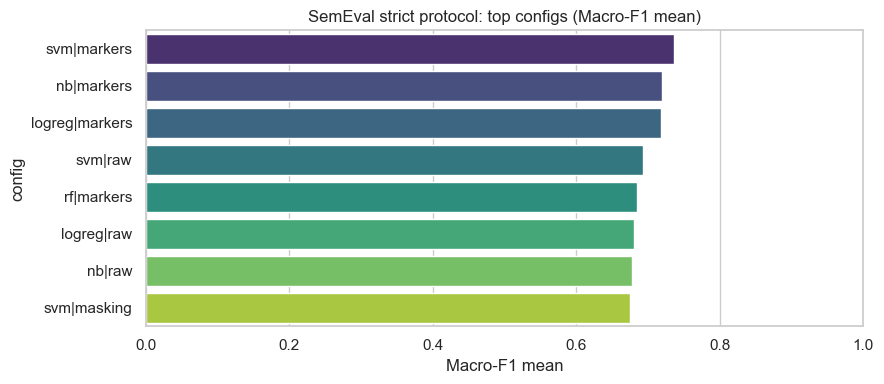

,dataset_key,status,parse_mode,rows,classes,imbalance_ratio_max_min,reason
0,sem_eval_2010_task_8:train,loaded,label_proxy,2766,14,1.204819,
1,ag_news:train,loaded,label_proxy,800,4,1.000000,
2,dbpedia_14:train,loaded,label_proxy,2800,14,1.000000,
3,yelp_polarity:train,loaded,label_proxy,400,2,1.000000,


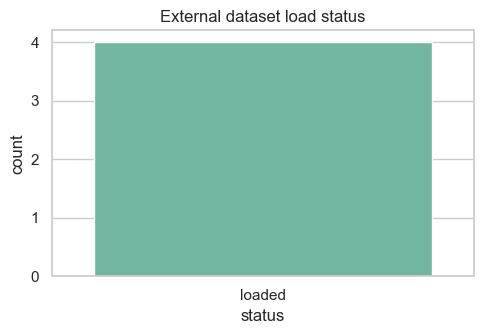

,dataset,source,model_name,f1_macro,mcc,pr_auc_macro
0,Synthetic-Imbalanced,internal stress,TF-IDF + LR,1.000000,1.000000,1.000000
1,Synthetic-Imbalanced,internal stress,SBERT + TorchHead (MiniLM),0.994582,0.993874,1.000000
2,dbpedia_14:train,external HF,SBERT + TorchHead (MiniLM),0.945616,0.942531,0.978878
3,dbpedia_14:train,external HF,TF-IDF + LR,0.926438,0.921423,0.969768
4,Synthetic-Noisy,internal stress,TF-IDF + LR,0.896751,0.862719,0.832263
5,Synthetic-Noisy,internal stress,SBERT + TorchHead (MiniLM),0.887223,0.850186,0.841048
6,ag_news:train,external HF,SBERT + TorchHead (MiniLM),0.849025,0.800292,0.911059
7,yelp_polarity:train,external HF,TF-IDF + LR,0.825000,0.650000,NaN
8,yelp_polarity:train,external HF,SBERT + TorchHead (MiniLM),0.800000,0.600000,NaN
9,ag_news:train,external HF,TF-IDF + LR,0.773220,0.702014,0.854890


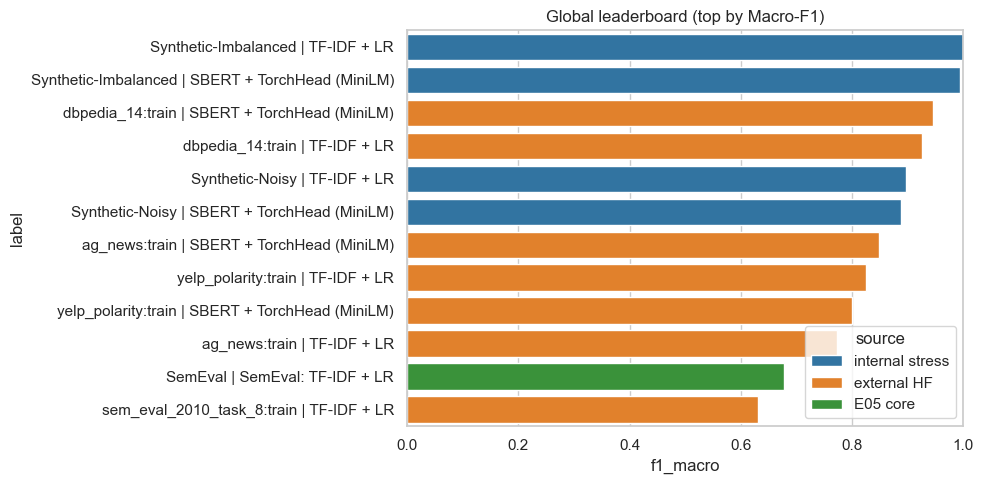

,insight,value
0,SemEval mode gap,markers beats masking by 0.053 Macro-F1
1,External parse modes,label_proxy: 4
2,Global best run,Synthetic-Imbalanced | TF-IDF + LR | Macro-F1=1.000


In [29]:
insight_rows = []

# 1) SemEval text-mode effect from expanded classical grid.
if "expanded_df" in globals() and not expanded_df.empty:
    sem_exp = expanded_df[expanded_df["dataset"] == "SemEval"].copy()
    if not sem_exp.empty:
        sem_mode_mean = (
            sem_exp.groupby("text_mode", as_index=False)[
                ["f1_macro", "mcc", "pr_auc_macro"]
            ]
            .mean()
            .sort_values("f1_macro", ascending=False)
        )
        display(sem_mode_mean)

        best_mode = sem_mode_mean.iloc[0]
        worst_mode = sem_mode_mean.iloc[-1]
        insight_rows.append(
            {
                "insight": "SemEval mode gap",
                "value": f"{best_mode['text_mode']} beats {worst_mode['text_mode']} by {(best_mode['f1_macro'] - worst_mode['f1_macro']):.3f} Macro-F1",
            }
        )

        plt.figure(figsize=(7, 4))
        sns.barplot(data=sem_mode_mean, x="text_mode", y="f1_macro", palette="crest")
        plt.title("SemEval: average Macro-F1 by text mode")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

        sem_model_mode = sem_exp.pivot_table(
            index="model_key", columns="text_mode", values="f1_macro", aggfunc="mean"
        )
        plt.figure(figsize=(7, 4))
        sns.heatmap(sem_model_mode, annot=True, fmt=".3f", cmap="YlGnBu")
        plt.title("SemEval: model x text mode (Macro-F1)")
        plt.tight_layout()
        plt.show()

# 2) Strict protocol stability (mean/std) for SemEval.
if "strict_summary" in globals() and not strict_summary.empty:
    sem_strict = strict_summary[strict_summary["dataset"] == "SemEval"].copy()
    if not sem_strict.empty:
        sem_strict_top = sem_strict.sort_values("f1_macro_mean", ascending=False).head(
            8
        )
        display(
            sem_strict_top[
                [
                    "model",
                    "text_mode",
                    "f1_macro_mean",
                    "f1_macro_std",
                    "mcc_mean",
                    "pr_auc_mean",
                ]
            ]
        )

        plt.figure(figsize=(9, 4))
        sns.barplot(
            data=sem_strict_top,
            x="f1_macro_mean",
            y=sem_strict_top["model"] + "|" + sem_strict_top["text_mode"],
            palette="viridis",
        )
        plt.title("SemEval strict protocol: top configs (Macro-F1 mean)")
        plt.xlim(0, 1)
        plt.xlabel("Macro-F1 mean")
        plt.ylabel("config")
        plt.tight_layout()
        plt.show()

# 3) External dataset status diagnostics.
if "external_catalog_df" in globals() and not external_catalog_df.empty:
    display(external_catalog_df)

    status_counts = (
        external_catalog_df["status"]
        .value_counts()
        .rename_axis("status")
        .reset_index(name="count")
    )
    plt.figure(figsize=(5, 3.5))
    sns.barplot(data=status_counts, x="status", y="count", palette="Set2")
    plt.title("External dataset load status")
    plt.tight_layout()
    plt.show()

    loaded_modes = external_catalog_df[external_catalog_df["status"] == "loaded"][
        "parse_mode"
    ].value_counts()
    if not loaded_modes.empty:
        insight_rows.append(
            {
                "insight": "External parse modes",
                "value": ", ".join([f"{k}: {v}" for k, v in loaded_modes.items()]),
            }
        )

# 4) Cross-dataset completed-run leaderboard.
leaderboard_parts = []

if "sem_summary" in globals() and not sem_summary.empty:
    sem_lb = sem_summary.copy()
    sem_lb["dataset"] = "SemEval"
    sem_lb["source"] = "E05 core"
    sem_lb = sem_lb.rename(columns={"model": "model_name"})
    leaderboard_parts.append(
        sem_lb[["dataset", "source", "model_name", "f1_macro", "mcc", "pr_auc_macro"]]
    )

if "extra_experiments_df" in globals() and not extra_experiments_df.empty:
    ex = extra_experiments_df[extra_experiments_df["status"] == "completed"].copy()
    if not ex.empty:
        ex = ex.rename(columns={"model": "model_name"})
        ex["source"] = "internal stress"
        leaderboard_parts.append(
            ex[["dataset", "source", "model_name", "f1_macro", "mcc", "pr_auc_macro"]]
        )

if "external_experiments_df" in globals() and not external_experiments_df.empty:
    ext = external_experiments_df[
        external_experiments_df["status"] == "completed"
    ].copy()
    if not ext.empty:
        ext = ext.rename(columns={"dataset_key": "dataset", "model": "model_name"})
        ext["source"] = "external HF"
        leaderboard_parts.append(
            ext[["dataset", "source", "model_name", "f1_macro", "mcc", "pr_auc_macro"]]
        )

if leaderboard_parts:
    global_leaderboard_df = pd.concat(leaderboard_parts, ignore_index=True)
    global_leaderboard_df = global_leaderboard_df.sort_values(
        "f1_macro", ascending=False
    ).reset_index(drop=True)
    display(global_leaderboard_df.head(20))

    top_for_plot = global_leaderboard_df.head(12).copy()
    top_for_plot["label"] = top_for_plot["dataset"] + " | " + top_for_plot["model_name"]

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=top_for_plot,
        x="f1_macro",
        y="label",
        hue="source",
        dodge=False,
        palette="tab10",
    )
    plt.title("Global leaderboard (top by Macro-F1)")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

    best_row = global_leaderboard_df.iloc[0]
    insight_rows.append(
        {
            "insight": "Global best run",
            "value": f"{best_row['dataset']} | {best_row['model_name']} | Macro-F1={best_row['f1_macro']:.3f}",
        }
    )

# 5) Build a concise insight table for report/poster text blocks.
if insight_rows:
    output_insights_df = pd.DataFrame(insight_rows)
    display(output_insights_df)
else:
    output_insights_df = pd.DataFrame(
        [{"insight": "No insights", "value": "Run all experiment cells first."}]
    )
    display(output_insights_df)

### 6.11) External Results Exploitation

,dataset_key,status,parse_mode,rows,classes,imbalance_ratio_max_min,reason
0,sem_eval_2010_task_8:train,loaded,label_proxy,2766,14,1.204819,
1,ag_news:train,loaded,label_proxy,800,4,1.000000,
2,dbpedia_14:train,loaded,label_proxy,2800,14,1.000000,
3,yelp_polarity:train,loaded,label_proxy,400,2,1.000000,


,parse_mode,count
0,label_proxy,4


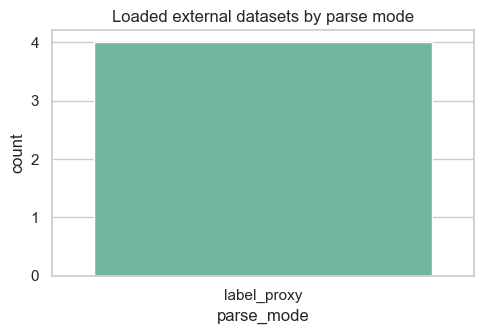

,dataset_key,model,f1_macro,mcc,pr_auc_macro,runtime_sec,f1_per_sec
3,ag_news:train,SBERT + TorchHead (MiniLM),0.849025,0.800292,0.911059,7.53,0.112752
2,ag_news:train,TF-IDF + LR,0.773220,0.702014,0.854890,0.05,15.464392
5,dbpedia_14:train,SBERT + TorchHead (MiniLM),0.945616,0.942531,0.978878,12.96,0.072964
4,dbpedia_14:train,TF-IDF + LR,0.926438,0.921423,0.969768,0.47,1.971144
0,sem_eval_2010_task_8:train,TF-IDF + LR,0.630405,0.617865,0.648756,0.26,2.424636
1,sem_eval_2010_task_8:train,SBERT + TorchHead (MiniLM),0.374154,0.358187,0.418430,10.70,0.034968
6,yelp_polarity:train,TF-IDF + LR,0.825000,0.650000,NaN,0.06,13.750000
7,yelp_polarity:train,SBERT + TorchHead (MiniLM),0.800000,0.600000,NaN,7.58,0.105541


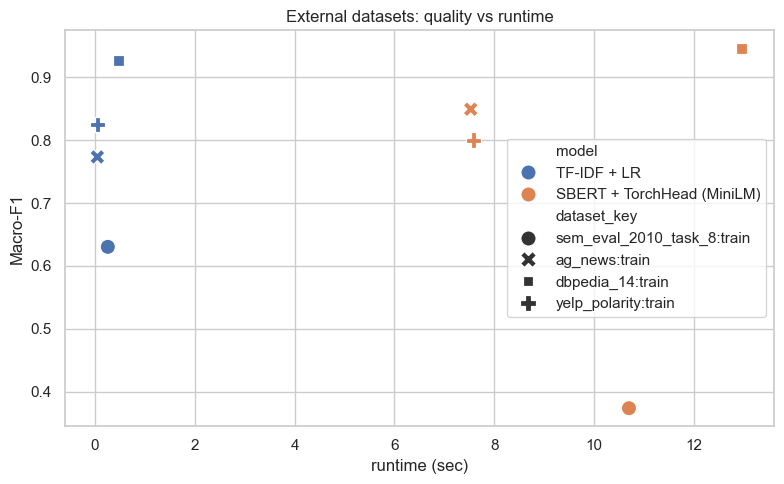

,dataset_key,f1_macro_TF-IDF + LR,f1_macro_SBERT + TorchHead (MiniLM),delta_f1_neural_minus_lr,runtime_sec_TF-IDF + LR,runtime_sec_SBERT + TorchHead (MiniLM),runtime_ratio_neural_over_lr
0,ag_news:train,0.773220,0.849025,0.075806,0.05,7.53,150.600000
1,dbpedia_14:train,0.926438,0.945616,0.019179,0.47,12.96,27.574468
3,yelp_polarity:train,0.825000,0.800000,-0.025000,0.06,7.58,126.333333
2,sem_eval_2010_task_8:train,0.630405,0.374154,-0.256251,0.26,10.70,41.153846


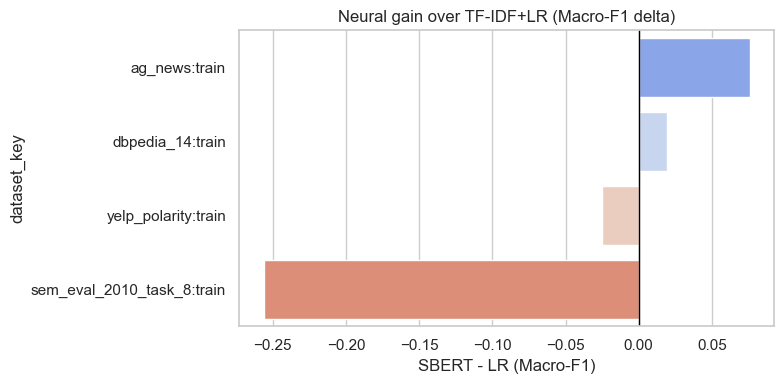

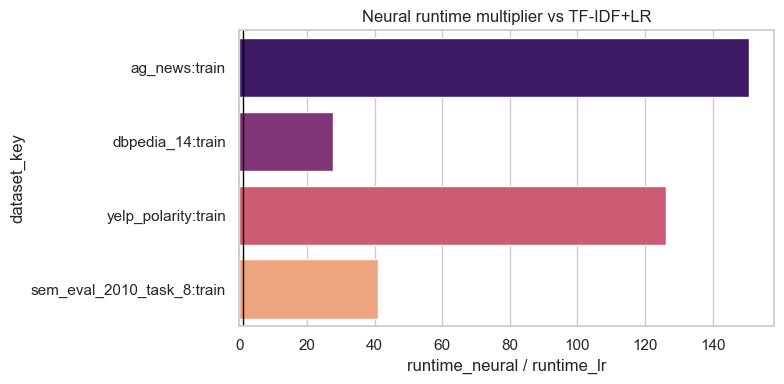

,dataset_key,delta_f1_neural_minus_lr,runtime_ratio_neural_over_lr,decision
0,ag_news:train,0.0758,150.60,Prefer neural for quality
1,dbpedia_14:train,0.0192,27.57,Quality tie: choose by latency/compute
2,yelp_polarity:train,-0.0250,126.33,Quality tie: choose by latency/compute
3,sem_eval_2010_task_8:train,-0.2563,41.15,Prefer TF-IDF+LR (neural underperforms)


,insight,value
0,SemEval mode gap,markers beats masking by 0.053 Macro-F1
1,External parse modes,label_proxy: 4
2,Global best run,Synthetic-Imbalanced | TF-IDF + LR | Macro-F1=1.000
3,External neural gain,"Best gain on ag_news:train: delta Macro-F1=+0.076, runtime x150.60"


In [30]:
if "external_catalog_df" in globals() and "external_experiments_df" in globals():
    # 1) Dataset-level status and parse-mode diagnostics.
    ext_catalog_view = external_catalog_df.copy()
    display(ext_catalog_view)

    loaded_ext = ext_catalog_view[ext_catalog_view["status"] == "loaded"].copy()
    parse_mode_counts = (
        loaded_ext["parse_mode"]
        .value_counts()
        .rename_axis("parse_mode")
        .reset_index(name="count")
    )
    if not parse_mode_counts.empty:
        display(parse_mode_counts)

        plt.figure(figsize=(5, 3.5))
        sns.barplot(data=parse_mode_counts, x="parse_mode", y="count", palette="Set2")
        plt.title("Loaded external datasets by parse mode")
        plt.tight_layout()
        plt.show()

    # 2) Completed-run table + quality/runtime views.
    ext_done = external_experiments_df[
        external_experiments_df["status"] == "completed"
    ].copy()
    if not ext_done.empty:
        ext_done = ext_done.dropna(subset=["f1_macro", "runtime_sec"])
        ext_done["f1_per_sec"] = ext_done["f1_macro"] / ext_done["runtime_sec"].clip(
            lower=1e-6
        )

        display(
            ext_done[
                [
                    "dataset_key",
                    "model",
                    "f1_macro",
                    "mcc",
                    "pr_auc_macro",
                    "runtime_sec",
                    "f1_per_sec",
                ]
            ].sort_values(["dataset_key", "f1_macro"], ascending=[True, False])
        )

        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=ext_done,
            x="runtime_sec",
            y="f1_macro",
            hue="model",
            style="dataset_key",
            s=120,
        )
        plt.title("External datasets: quality vs runtime")
        plt.xlabel("runtime (sec)")
        plt.ylabel("Macro-F1")
        plt.tight_layout()
        plt.show()

        # 3) Per-dataset neural vs classical deltas.
        pair = ext_done.pivot_table(
            index="dataset_key",
            columns="model",
            values=["f1_macro", "runtime_sec"],
            aggfunc="mean",
        )
        if (
            ("f1_macro", "TF-IDF + LR") in pair.columns
            and ("f1_macro", "SBERT + TorchHead (MiniLM)") in pair.columns
            and ("runtime_sec", "TF-IDF + LR") in pair.columns
            and ("runtime_sec", "SBERT + TorchHead (MiniLM)") in pair.columns
        ):
            pair = pair.copy()
            pair["delta_f1_neural_minus_lr"] = (
                pair[("f1_macro", "SBERT + TorchHead (MiniLM)")]
                - pair[("f1_macro", "TF-IDF + LR")]
            )
            pair["runtime_ratio_neural_over_lr"] = pair[
                ("runtime_sec", "SBERT + TorchHead (MiniLM)")
            ] / pair[("runtime_sec", "TF-IDF + LR")].clip(lower=1e-6)
            pair = pair.reset_index()
            pair.columns = ["dataset_key"] + [
                "_".join(c).strip("_") if isinstance(c, tuple) else c
                for c in pair.columns[1:]
            ]

            delta_view = pair[
                [
                    "dataset_key",
                    "f1_macro_TF-IDF + LR",
                    "f1_macro_SBERT + TorchHead (MiniLM)",
                    "delta_f1_neural_minus_lr",
                    "runtime_sec_TF-IDF + LR",
                    "runtime_sec_SBERT + TorchHead (MiniLM)",
                    "runtime_ratio_neural_over_lr",
                ]
            ].sort_values("delta_f1_neural_minus_lr", ascending=False)
            display(delta_view)

            plt.figure(figsize=(8, 4))
            sns.barplot(
                data=delta_view,
                x="delta_f1_neural_minus_lr",
                y="dataset_key",
                palette="coolwarm",
            )
            plt.axvline(0, color="black", lw=1)
            plt.title("Neural gain over TF-IDF+LR (Macro-F1 delta)")
            plt.xlabel("SBERT - LR (Macro-F1)")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8, 4))
            sns.barplot(
                data=delta_view,
                x="runtime_ratio_neural_over_lr",
                y="dataset_key",
                palette="magma",
            )
            plt.axvline(1.0, color="black", lw=1)
            plt.title("Neural runtime multiplier vs TF-IDF+LR")
            plt.xlabel("runtime_neural / runtime_lr")
            plt.tight_layout()
            plt.show()

            # 4) Actionable table for report/poster recommendations.
            recs = []
            for _, r in delta_view.iterrows():
                if r["delta_f1_neural_minus_lr"] >= 0.03:
                    decision = "Prefer neural for quality"
                elif r["delta_f1_neural_minus_lr"] <= -0.03:
                    decision = "Prefer TF-IDF+LR (neural underperforms)"
                else:
                    decision = "Quality tie: choose by latency/compute"

                recs.append(
                    {
                        "dataset_key": r["dataset_key"],
                        "delta_f1_neural_minus_lr": round(
                            float(r["delta_f1_neural_minus_lr"]), 4
                        ),
                        "runtime_ratio_neural_over_lr": round(
                            float(r["runtime_ratio_neural_over_lr"]), 2
                        ),
                        "decision": decision,
                    }
                )

            external_decision_df = pd.DataFrame(recs)
            display(external_decision_df)

            # Bridge these findings into global insights if available.
            if "output_insights_df" in globals() and not external_decision_df.empty:
                best_gain_row = external_decision_df.sort_values(
                    "delta_f1_neural_minus_lr", ascending=False
                ).iloc[0]
                new_row = pd.DataFrame(
                    [
                        {
                            "insight": "External neural gain",
                            "value": (
                                f"Best gain on {best_gain_row['dataset_key']}: "
                                f"delta Macro-F1={best_gain_row['delta_f1_neural_minus_lr']:+.3f}, "
                                f"runtime x{best_gain_row['runtime_ratio_neural_over_lr']:.2f}"
                            ),
                        }
                    ]
                )
                output_insights_df = pd.concat(
                    [output_insights_df, new_row], ignore_index=True
                )
                display(output_insights_df)
    else:
        print(
            "No completed external runs found yet. Re-run external experiment cell first."
        )
else:
    print("External tables not found. Run section 6.3.3 first.")

### 6.12) KG Output

,primary_target,selection_rule,external_signal
0,SemEval KG-style relation output,Use best available SemEval model from sem_summary,Neural-preferred share on external datasets: 0.25


KG model used: TF-IDF + LR


,pred_relation,accept_threshold,review_threshold
2,Entity-Destination,0.843323,0.716824
0,Cause-Effect,0.834102,0.708987
1,Component-Whole,0.568776,0.483460
3,Product-Producer,0.507297,0.431202


,queue,count
0,reject,360
1,accept,156
2,review,103


,e1,pred_relation,e2,confidence,accept_threshold
472,metacorpora,Entity-Destination,isthmus,0.992978,0.843323
413,catastrophe,Cause-Effect,spill,0.990386,0.834102
253,needle,Entity-Destination,machine,0.983997,0.843323
128,water,Entity-Destination,seeds,0.983459,0.843323
305,tides,Cause-Effect,gravitational force,0.982132,0.834102
157,cysteamine,Entity-Destination,gastric juice,0.975844,0.843323
99,panda,Entity-Destination,park,0.974825,0.843323
259,chip,Entity-Destination,pet,0.973684,0.843323
411,toxic materials,Entity-Destination,water,0.965707,0.843323
170,cells,Entity-Destination,patient,0.959299,0.843323


,e1,pred_relation,e2,confidence,review_threshold
583,plight,Entity-Destination,dwellers,0.842613,0.716824
257,boss,Entity-Destination,office,0.834743,0.716824
267,earthquake,Cause-Effect,blackout,0.829732,0.708987
540,Bounding pulses,Cause-Effect,arterial blood pressure,0.828443,0.708987
328,drug,Cause-Effect,death,0.827355,0.708987
402,Ants,Entity-Destination,habitats,0.822531,0.716824
167,devastations,Cause-Effect,storms,0.822105,0.708987
451,protein,Entity-Destination,diet,0.818277,0.716824
92,heroin,Entity-Destination,puppies,0.815445,0.716824
416,inflammation,Cause-Effect,irritants,0.811687,0.708987


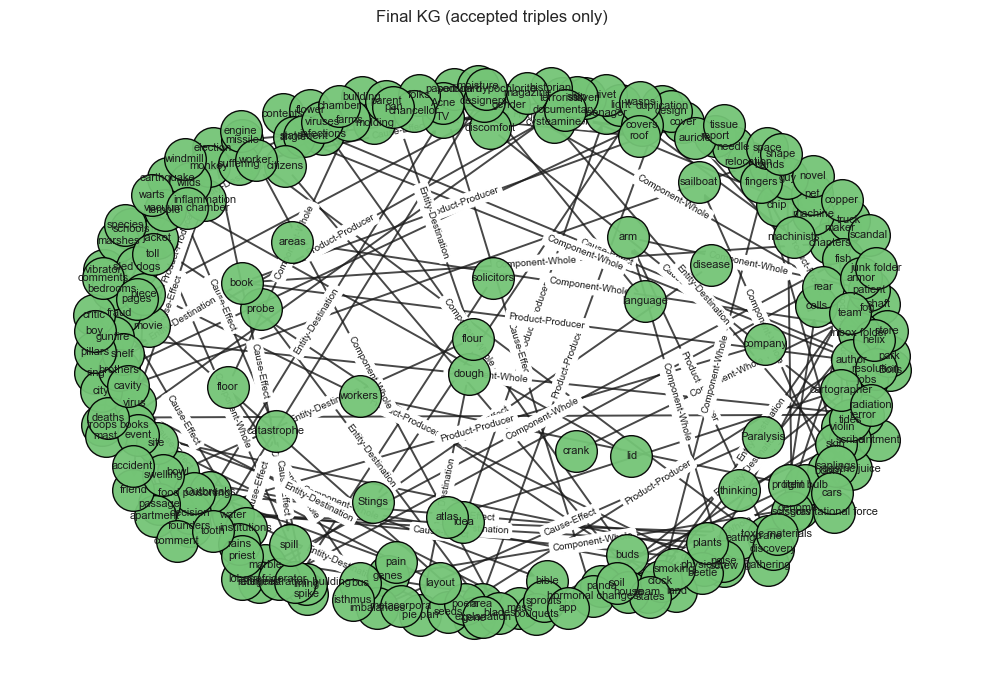

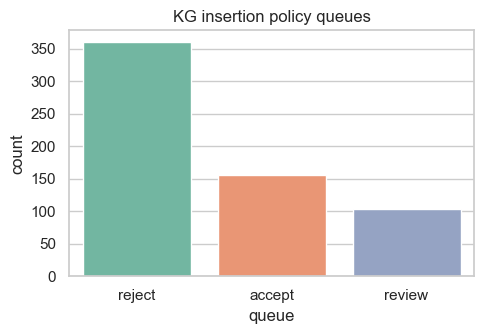

In [32]:
kg_strategy_note = {
    "primary_target": "SemEval KG-style relation output",
    "selection_rule": "Use best available SemEval model from sem_summary",
}

if "external_decision_df" in globals() and not external_decision_df.empty:
    neural_pref_share = (external_decision_df["decision"] == "Prefer neural for quality").mean()
    kg_strategy_note["external_signal"] = (
        f"Neural-preferred share on external datasets: {neural_pref_share:.2f}"
    )
else:
    kg_strategy_note["external_signal"] = "No external decision table available"

# Pick SemEval prediction source from already computed artifacts.
kg_sem_df = None
kg_sem_pred = None
kg_sem_prob = None
kg_sem_labels = None
kg_model_used = "unknown"

if "sem_summary" in globals() and not sem_summary.empty:
    top_sem_model = sem_summary.iloc[0]["model"]
    if (
        isinstance(top_sem_model, str)
        and top_sem_model.startswith("SemEval: SBERT + TorchHead [")
        and "sem_nn_artifacts" in globals()
    ):
        emb = top_sem_model.split("[", 1)[1].rstrip("]")
        if emb in sem_nn_artifacts:
            kg_sem_df, kg_sem_pred, kg_sem_prob, kg_sem_labels = sem_nn_artifacts[emb]
            kg_model_used = f"Neural ({emb})"

if kg_sem_df is None and "sem_test_lr" in globals():
    kg_sem_df = sem_test_lr.copy()
    kg_sem_pred = sem_pred_lr
    kg_sem_prob = sem_prob_lr
    kg_sem_labels = sem_labels_lr
    kg_model_used = "TF-IDF + LR"

if kg_sem_df is None:
    print("No SemEval prediction artifacts available. Run section 6.3 first.")
else:
    kg_out_df = kg_sem_df[["sentence", "e1", "e2", "relation"]].copy()
    kg_out_df["pred_relation"] = kg_sem_pred
    kg_out_df["confidence"] = kg_sem_prob.max(axis=1)

    # Drop non-actionable class for KG insertion.
    kg_action_df = kg_out_df[~kg_out_df["pred_relation"].isin(["Other", "NONE"])].copy()

    # Per-relation confidence thresholds from prediction distribution.
    rel_thr = (
        kg_action_df.groupby("pred_relation")["confidence"]
        .quantile(0.75)
        .rename("accept_threshold")
        .reset_index()
    )
    rel_thr["review_threshold"] = (rel_thr["accept_threshold"] * 0.85).clip(upper=0.95)

    kg_scored = kg_action_df.merge(rel_thr, on="pred_relation", how="left")
    kg_scored["queue"] = np.where(
        kg_scored["confidence"] >= kg_scored["accept_threshold"],
        "accept",
        np.where(
            kg_scored["confidence"] >= kg_scored["review_threshold"], "review", "reject"
        ),
    )

    kg_policy_summary = (
        kg_scored["queue"]
        .value_counts()
        .rename_axis("queue")
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    display(pd.DataFrame([kg_strategy_note]))
    print(f"KG model used: {kg_model_used}")
    display(rel_thr.sort_values("accept_threshold", ascending=False))
    display(kg_policy_summary)

    accepted_triples_df = kg_scored[kg_scored["queue"] == "accept"].copy()
    review_triples_df = kg_scored[kg_scored["queue"] == "review"].copy()

    display(
        accepted_triples_df[
            ["e1", "pred_relation", "e2", "confidence", "accept_threshold"]
        ]
        .sort_values("confidence", ascending=False)
        .head(20)
    )
    display(
        review_triples_df[
            ["e1", "pred_relation", "e2", "confidence", "review_threshold"]
        ]
        .sort_values("confidence", ascending=False)
        .head(20)
    )

    # Final accepted-KG visualization.
    accepted_triplets = list(
        dict.fromkeys(
            list(
                zip(
                    accepted_triples_df["e1"],
                    accepted_triples_df["pred_relation"],
                    accepted_triples_df["e2"],
                )
            )
        )
    )[:120]

    if accepted_triplets:
        G_acc = nx.DiGraph()
        for h, rel, t in accepted_triplets:
            G_acc.add_edge(h, t, relation=rel)

        plt.figure(figsize=(10, 7))
        pos = nx.spring_layout(G_acc, seed=SEED, k=0.9)
        nx.draw_networkx_nodes(
            G_acc,
            pos,
            node_size=900,
            node_color="#74c476",
            edgecolors="black",
            alpha=0.95,
        )
        nx.draw_networkx_labels(G_acc, pos, font_size=8)
        nx.draw_networkx_edges(G_acc, pos, arrows=True, width=1.4, alpha=0.8)
        e_labels = nx.get_edge_attributes(G_acc, "relation")
        nx.draw_networkx_edge_labels(
            G_acc, pos, edge_labels=dict(list(e_labels.items())[:70]), font_size=7
        )
        plt.title("Final KG (accepted triples only)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print("No accepted triples under current thresholds.")

    # Queue distribution visualization for poster.
    plt.figure(figsize=(5, 3.5))
    sns.barplot(data=kg_policy_summary, x="queue", y="count", palette="Set2")
    plt.title("KG insertion policy queues")
    plt.tight_layout()
    plt.show()